In [ ]:
# General libraries
import os
import glob
import json
import random
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision and timm for pre-trained models and transforms
import torchvision.transforms as transforms
from torchvision import models
import timm

# Rasterio for reading TIFF images
!pip install rasterio --quiet
import rasterio

# PIL for image processing
from PIL import Image

# Mixed precision training (if desired)
from torch.amp import autocast, GradScaler

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Environment set up. Device:", device)

Environment set up. Device: cuda


In [ ]:
# === Utils: logging, latency, bootstrap ===
import json, time, pathlib, platform, os
from pathlib import Path
import numpy as np
from collections import OrderedDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

WORKDIR = Path("/kaggle/working"); WORKDIR.mkdir(exist_ok=True, parents=True)

def save_json(obj, path):
    with open(path, "w") as f: json.dump(obj, f, indent=2)

def torch_inference_latency(model, device, shape=(1,3,256,256), n_warmup=50, n_iter=200):
    model.eval(); x = torch.randn(*shape, device=device)
    with torch.inference_mode():
        for _ in range(n_warmup): _ = model(x)
    times=[]
    with torch.inference_mode():
        for _ in range(n_iter):
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter(); _ = model(x)
            if device.type == "cuda": torch.cuda.synchronize()
            times.append((time.perf_counter()-t0)*1000.0)
    return float(np.median(times)), float(np.mean(times)), float(np.std(times))

def bootstrap_ci_binary(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed); n = len(y_true)
    accs=[]; precs=[]; recs=[]; f1s=[]
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]; yp = y_pred[idx]
        accs.append(accuracy_score(yt, yp))
        p,r,f1,_ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
        precs.append(p); recs.append(r); f1s.append(f1)
    def ci(a): a=np.array(a); return float(a.mean()), (float(np.percentile(a,2.5)), float(np.percentile(a,97.5)))
    return {"acc": ci(accs), "prec": ci(precs), "rec": ci(recs), "f1": ci(f1s)}


In [ ]:
# === Helper to log per-model hyperparams ===
import json
def log_model_hparams(model_name,
                      optimizer,
                      num_epochs,
                      patience,
                      early_stop_threshold,
                      img_size,
                      batch_size,
                      notes=None,
                      path=WORKDIR/"hparams_models.json"):
    # Grab base LR & WD from the first param group (standard PyTorch pattern)
    # (Schedulers use scheduler.get_last_lr(); here we log configured LR directly.)
    lr = float(optimizer.param_groups[0]["lr"])
    wd = float(optimizer.param_groups[0].get("weight_decay", 0.0))

    payload = {
        "optimizer": optimizer.__class__.__name__,
        "lr": lr,
        "weight_decay": wd,
        "epochs": int(num_epochs),
        "early_stopping_patience": int(patience),
        "early_stop_threshold": float(early_stop_threshold),
        "image_size": int(img_size),
        "batch_size": int(getattr(train_loader, "batch_size", -1)),  # adapt if different
        "notes": notes or {}
    }

    # Merge into a single file keyed by model name
    try:
        with open(path, "r") as f:
            data = json.load(f)
    except FileNotFoundError:
        data = {}
    data[model_name] = payload
    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"[hparams] logged for {model_name} -> {path}")


Total TIFF files found: 36053
Sample file paths:
/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD/new.tif
/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD/0111/S1B_IW_GRDH_1SDV_20190202T182548_20190202T182613_014771_01B8C5_F9C2_corrected_VV.tif
/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD/0111/S2_2019-02-11_B05.tif
/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD/0111/S2_2019-02-11_B06.tif
/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD/0111/S2_2019-02-11_B11.tif


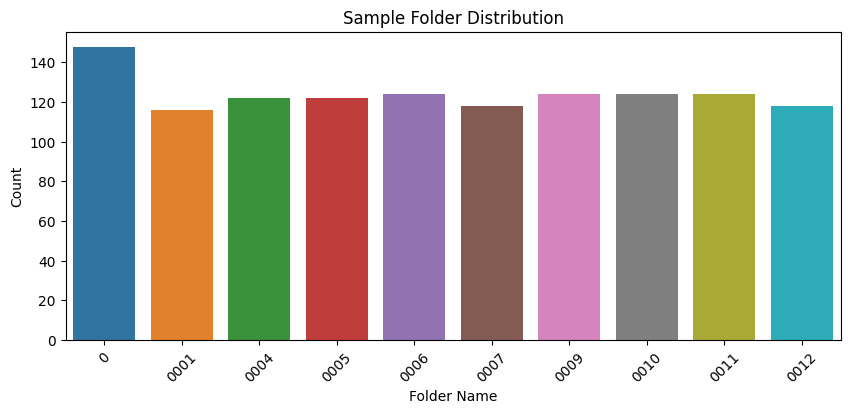

In [ ]:
# Define dataset directory (adjust as needed)
data_dir = "/kaggle/input/sen12flood-flood-detection-dataset/SEN12FLOOD"

# List all TIFF files recursively
tif_files = glob.glob(os.path.join(data_dir, "**/*.tif"), recursive=True)
print(f"Total TIFF files found: {len(tif_files)}")

# Print a sample of file paths to see the diversity (they may include Sentinel-1 and Sentinel-2 files)
print("Sample file paths:")
for f in tif_files[:5]:
    print(f)

# Optionally, plot a histogram of folder names to see the sensor or region distribution
folder_names = [os.path.basename(os.path.dirname(file)) for file in tif_files]
folder_counts = Counter(folder_names)

# Convert folder_counts (a Counter) into a DataFrame
df_folder_counts = pd.DataFrame(list(folder_counts.items()), columns=["Folder", "Count"])

# Sort by folder name or count if desired (here we just show the first 10 sorted by folder name)
df_folder_counts = df_folder_counts.sort_values("Folder").head(10)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_folder_counts, x="Folder", y="Count")
plt.title("Sample Folder Distribution")
plt.xlabel("Folder Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Load JSON files for metadata (adjust paths if needed)
s1_json_path = os.path.join(data_dir, "S1list.json")
s2_json_path = os.path.join(data_dir, "S2list.json")

with open(s1_json_path, "r") as f:
    s1_data = json.load(f)
with open(s2_json_path, "r") as f:
    s2_data = json.load(f)

# Build label mapping from folder names to flood labels
flood_labels = {}
# Example logic for Sentinel-1 data (adjust based on actual JSON structure)
for folder, details in s1_data.items():
    flood_status = any(
        entry.get("FLOODING", False)
        for key, entry in details.items()
        if isinstance(entry, dict) and "FLOODING" in entry
    )
    flood_labels[folder] = int(flood_status)

# Update mapping using Sentinel-2 data if applicable
for folder, details in s2_data.items():
    flood_status = any(
        entry.get("FLOODING", False)
        for key, entry in details.items()
        if isinstance(entry, dict) and "FLOODING" in entry
    )
    flood_labels[folder] = int(flood_status)

# Verify mapping
print("Flood Label Mapping (Sample):")
for folder, label in list(flood_labels.items())[:10]:
    print(f"Folder: {folder}, Flooding: {label}")

# Check overall label distribution in the dataset using folder names from TIFF files
dataset_folder_names = [os.path.basename(os.path.dirname(file)) for file in tif_files]
mapped_labels = [flood_labels.get(folder, 0) for folder in dataset_folder_names]
print("Label Distribution in Dataset:", Counter(mapped_labels))

Flood Label Mapping (Sample):
Folder: 0063, Flooding: 0
Folder: 0200, Flooding: 1
Folder: 0004, Flooding: 0
Folder: 0307, Flooding: 1
Folder: 0167, Flooding: 1
Folder: 0205, Flooding: 1
Folder: 0166, Flooding: 1
Folder: 0240, Flooding: 1
Folder: 0123, Flooding: 0
Folder: 61, Flooding: 1
Label Distribution in Dataset: Counter({1: 24333, 0: 11720})


Sensor distribution:
sensor
Sentinel-2    26844
Sentinel-1     9208
Other             1
Name: count, dtype: int64


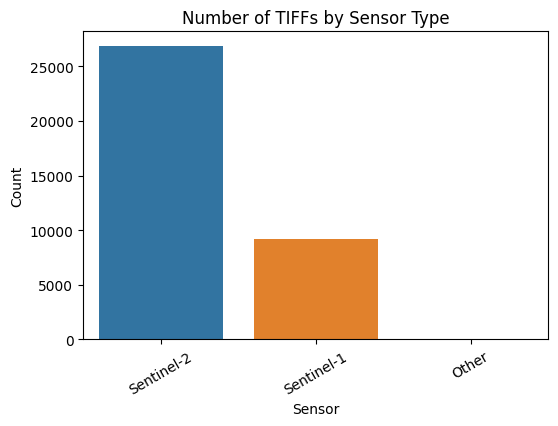

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classify each TIFF by sensor type based on its path or filename
sensor_types = []
for path in tif_files:
    fname = os.path.basename(path)
    if "/S1" in path or fname.startswith("S1"):
        sensor_types.append("Sentinel-1")
    elif "/S2" in path or fname.startswith("S2"):
        sensor_types.append("Sentinel-2")
    else:
        sensor_types.append("Other")

# Build a DataFrame and count
df_sensors = pd.DataFrame({"path": tif_files, "sensor": sensor_types})
counts = df_sensors["sensor"].value_counts()

print("Sensor distribution:")
print(counts)

# Bar plot for visual inspection
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Number of TIFFs by Sensor Type")
plt.ylabel("Count")
plt.xlabel("Sensor")
plt.xticks(rotation=30)
plt.show()

In [ ]:
import os
import pandas as pd

# We already have `tif_files` and `sensor_types` from before, but let's rebuild succinctly:
sensor_classification = []
for path in tif_files:
    if "/S1" in path or os.path.basename(path).startswith("S1"):
        sensor_classification.append("Sentinel-1")
    elif "/S2" in path or os.path.basename(path).startswith("S2"):
        sensor_classification.append("Sentinel-2")
    else:
        sensor_classification.append("Other")

df_sensors = pd.DataFrame({
    "filepath": tif_files,
    "sensor": sensor_classification
})

# Split into lists
sentinel1_files = df_sensors[df_sensors.sensor == "Sentinel-1"]["filepath"].tolist()
sentinel2_files = df_sensors[df_sensors.sensor == "Sentinel-2"]["filepath"].tolist()
other_files     = df_sensors[df_sensors.sensor == "Other"]["filepath"].tolist()

print(f"Sentinel‑1 count: {len(sentinel1_files)}")
print(f"Sentinel‑2 count: {len(sentinel2_files)}")
print(f"Other count:      {len(other_files)}")

Sentinel‑1 count: 9208
Sentinel‑2 count: 26844
Other count:      1


In [ ]:
import rasterio
import numpy as np

def load_s2_true_color_stretched(prefix: str, band_map=None, pmin=2, pmax=98):
    """
    Given a prefix (folder) for Sentinel-2 single-band TIFFs, read bands 04,03,02,
    then apply a per-channel percentile stretch (default 2–98%) and return an
    8-bit RGB image.

    Parameters
    ----------
    prefix   : str
      The folder name (e.g. '0111') or any key into your s2_folder_groups dict.
    band_map : dict, optional
      Maps 'R','G','B' to band strings (default {'R':'04','G':'03','B':'02'}).
    pmin, pmax : float
      Percentiles for lower/upper clip.

    Returns
    -------
    np.ndarray
      uint8 RGB image of shape (H, W, 3).
    """
    if band_map is None:
        band_map = {'R':'04','G':'03','B':'02'}

    grp = s2_folder_groups[prefix]
    chans = {}
    for col, b in band_map.items():
        with rasterio.open(grp[b]) as src:
            chans[col] = src.read(1).astype(float)

    # Build the 3‐channel array
    arr = np.stack([chans['R'], chans['G'], chans['B']], axis=-1)

    # Per‐channel percentile stretch
    out = np.zeros_like(arr)
    for i, col in enumerate(['R','G','B']):
        band = arr[..., i]
        lo, hi = np.percentile(band, (pmin, pmax))
        band = np.clip(band, lo, hi)
        out[..., i] = ( (band - lo) / (hi - lo) * 255 )

    return out.astype(np.uint8)

In [ ]:
import os
import random

# ---- Sentinel-1 sampling ----
s1_flooded = [fp for fp in sentinel1_files if flood_labels.get(os.path.basename(os.path.dirname(fp)), 0) == 1]
s1_non     = [fp for fp in sentinel1_files if flood_labels.get(os.path.basename(os.path.dirname(fp)), 0) == 0]

n = 5
s1_flooded_samples = random.sample(s1_flooded, min(len(s1_flooded), n))
s1_non_samples     = random.sample(s1_non,     min(len(s1_non),     n))

print(f"Sentinel-1: sampled {len(s1_flooded_samples)} flooded, {len(s1_non_samples)} non-flooded images")

# ---- Sentinel-2 sampling via B04 files ----
s2_b04 = [fp for fp in sentinel2_files if fp.endswith("_B04.tif")]

s2_b04_flooded = [fp for fp in s2_b04 if flood_labels.get(os.path.basename(os.path.dirname(fp)), 0) == 1]
s2_b04_non     = [fp for fp in s2_b04 if flood_labels.get(os.path.basename(os.path.dirname(fp)), 0) == 0]

s2_b04_flooded_samples = random.sample(s2_b04_flooded, min(len(s2_b04_flooded), n))
s2_b04_non_samples     = random.sample(s2_b04_non,     min(len(s2_b04_non),     n))

print(f"Sentinel-2: sampled {len(s2_b04_flooded_samples)} flooded, {len(s2_b04_non_samples)} non-flooded B04 files")


Sentinel-1: sampled 5 flooded, 5 non-flooded images
Sentinel-2: sampled 5 flooded, 5 non-flooded B04 files


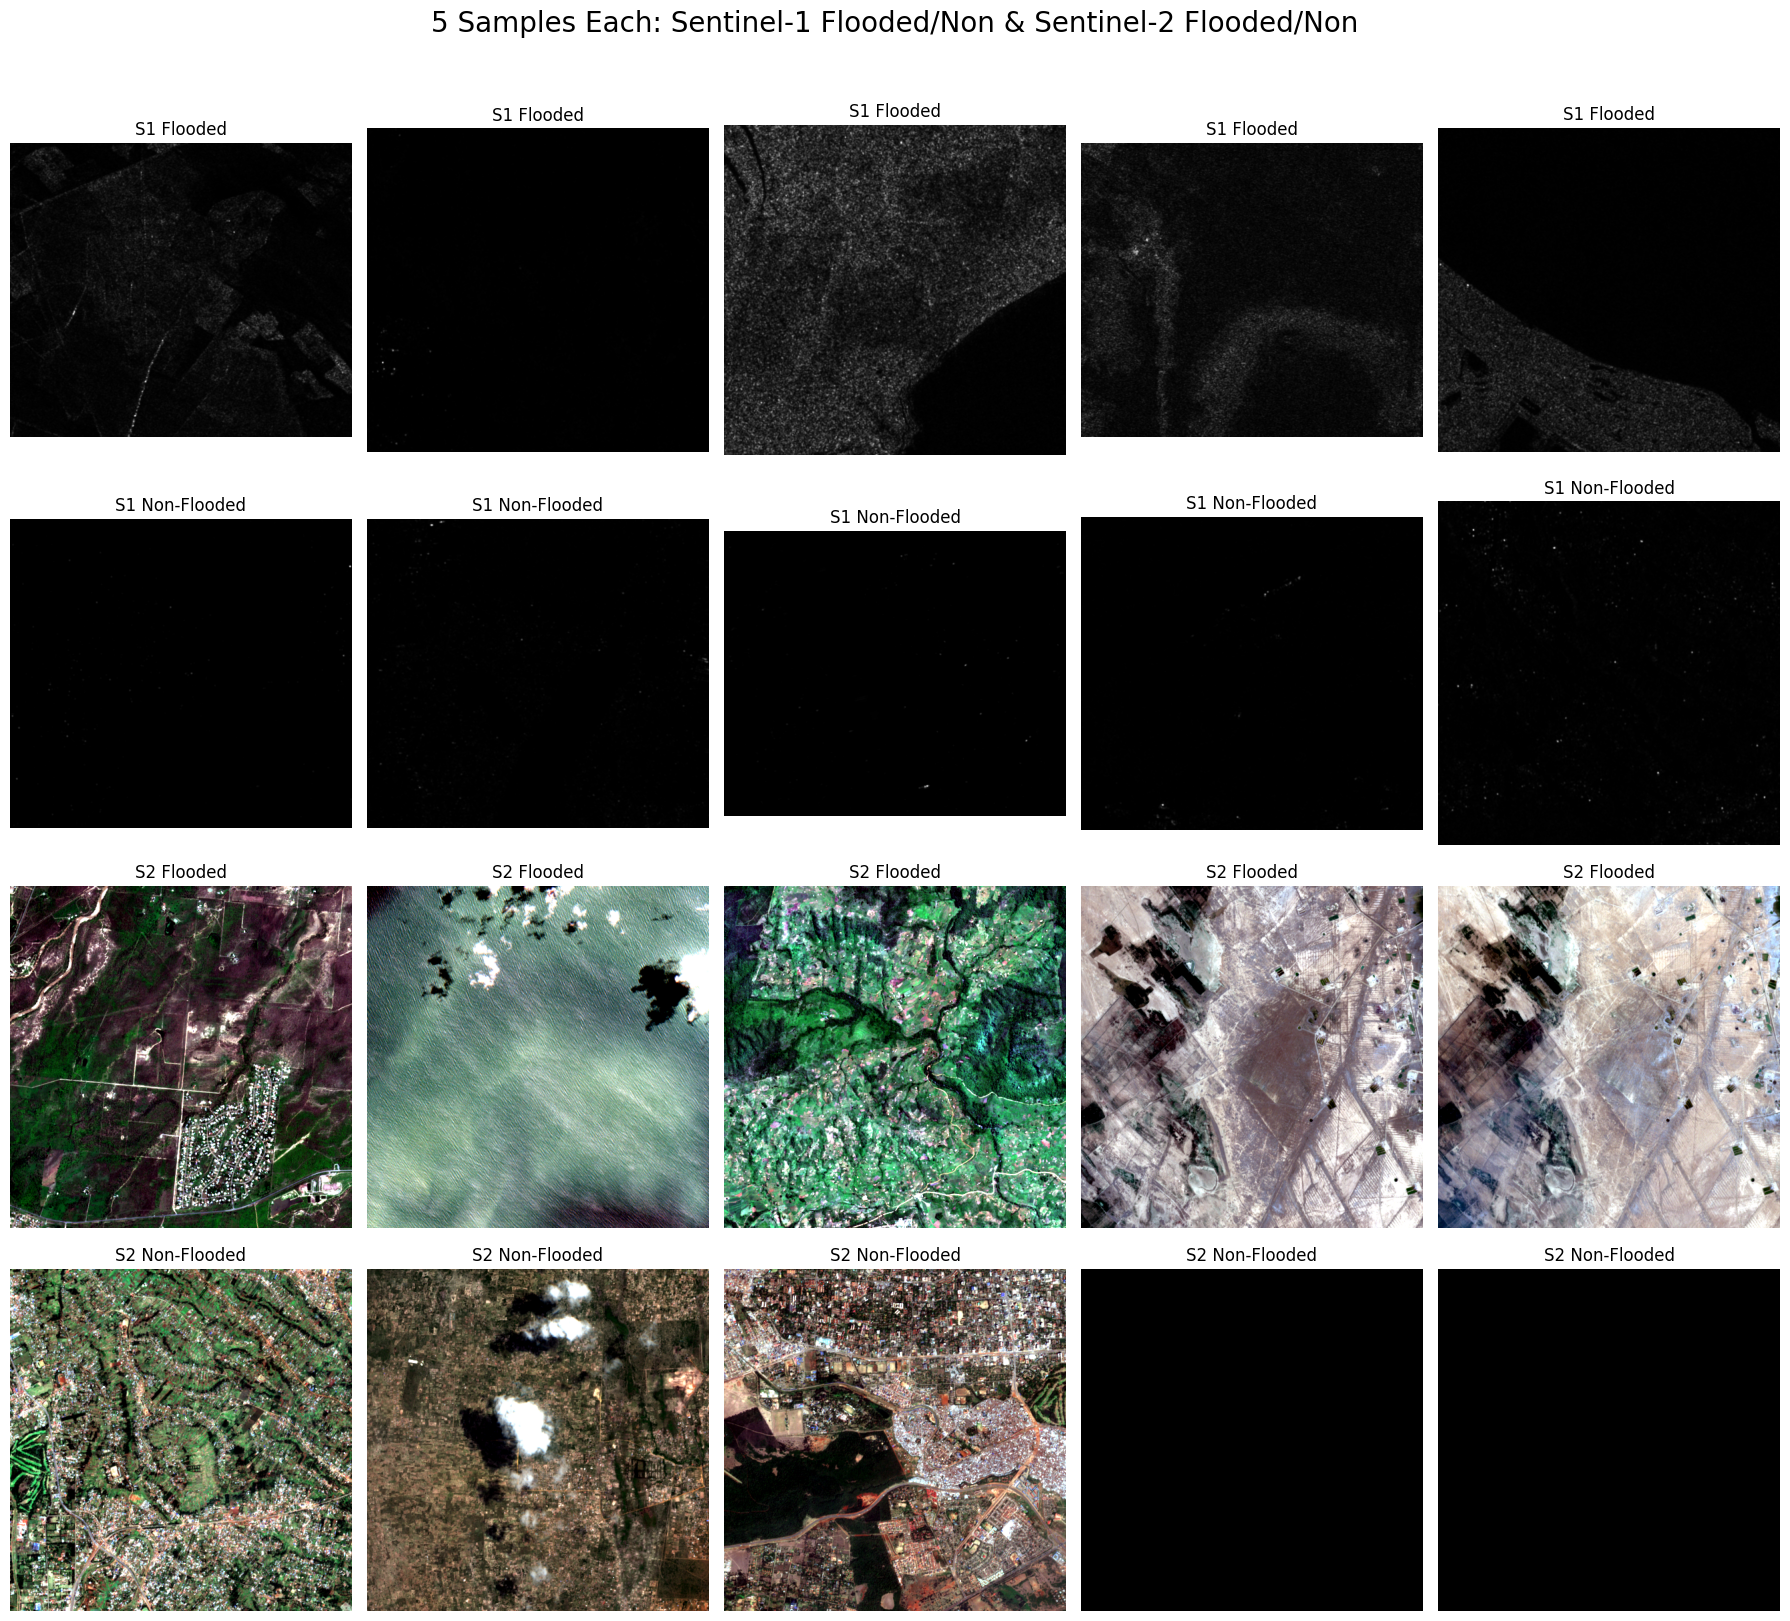

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

def load_s1_gray(fp):
    """Load Sentinel‑1 band1, stretch to 0–255 uint8."""
    with rasterio.open(fp) as src:
        arr = src.read(1).astype(float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    if hi>lo: arr=(arr-lo)/(hi-lo)
    else:     arr=np.zeros_like(arr)
    return (arr*255).astype(np.uint8)

def load_s2_true_color(b04_fp):
    """
    Given a B04 filepath, infer the B03 and B02 paths by filename,
    load all three, then per‑band min‑max stretch.
    """
    base = b04_fp[:-8]  # strip "_B04.tif"
    fR = b04_fp
    fG = base + "_B03.tif"
    fB = base + "_B02.tif"
    with rasterio.open(fR) as r, rasterio.open(fG) as g, rasterio.open(fB) as b:
        R = r.read(1).astype(float)
        G = g.read(1).astype(float)
        B = b.read(1).astype(float)
    out = np.stack([R,G,B], axis=-1)
    for i in range(3):
        ch = out[...,i]
        lo, hi = np.nanpercentile(ch, (2,98))
        ch = np.clip(ch, lo, hi)
        out[...,i] = (ch - lo)/(hi-lo) if hi>lo else np.zeros_like(ch)
    return (out*255).astype(np.uint8)

# Build figure
fig, axes = plt.subplots(4, 5, figsize=(18,16))

# Row 0: S1 flooded
for i, fp in enumerate(s1_flooded_samples):
    axes[0,i].imshow(load_s1_gray(fp), cmap="gray")
    axes[0,i].set_title("S1 Flooded")
    axes[0,i].axis("off")

# Row 1: S1 non‑flooded
for i, fp in enumerate(s1_non_samples):
    axes[1,i].imshow(load_s1_gray(fp), cmap="gray")
    axes[1,i].set_title("S1 Non‑Flooded")
    axes[1,i].axis("off")

# Row 2: S2 flooded
for i, fp in enumerate(s2_b04_flooded_samples):
    axes[2,i].imshow(load_s2_true_color(fp))
    axes[2,i].set_title("S2 Flooded")
    axes[2,i].axis("off")

# Row 3: S2 non‑flooded
for i, fp in enumerate(s2_b04_non_samples):
    axes[3,i].imshow(load_s2_true_color(fp))
    axes[3,i].set_title("S2 Non‑Flooded")
    axes[3,i].axis("off")

plt.suptitle("5 Samples Each: Sentinel‑1 Flooded/Non & Sentinel‑2 Flooded/Non", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Number of flooded images: 24333
Number of non-flooded images: 11720


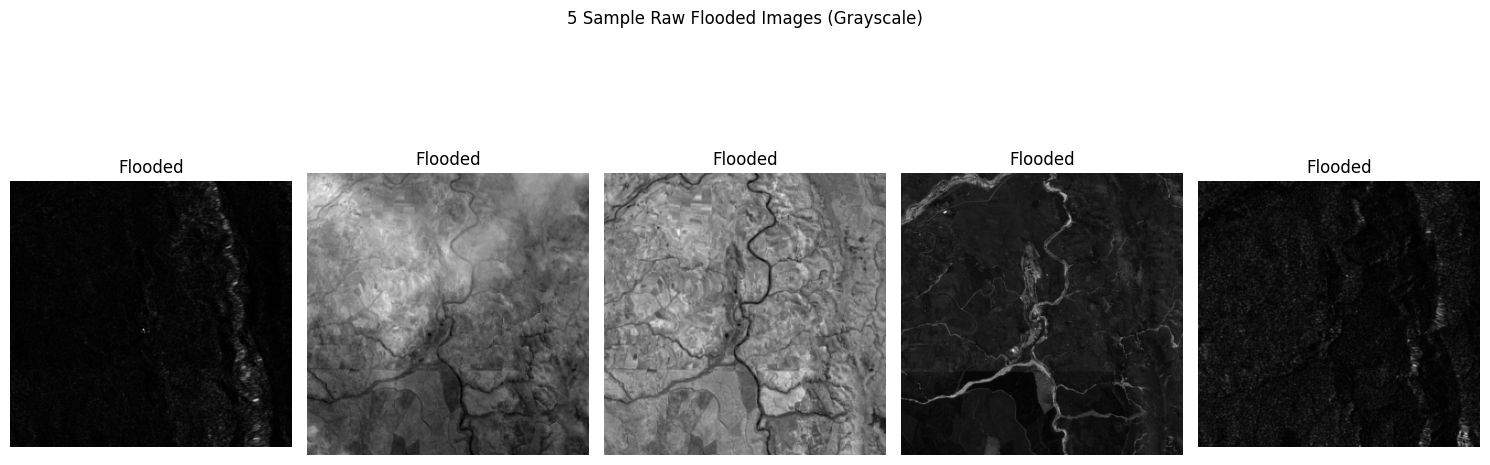

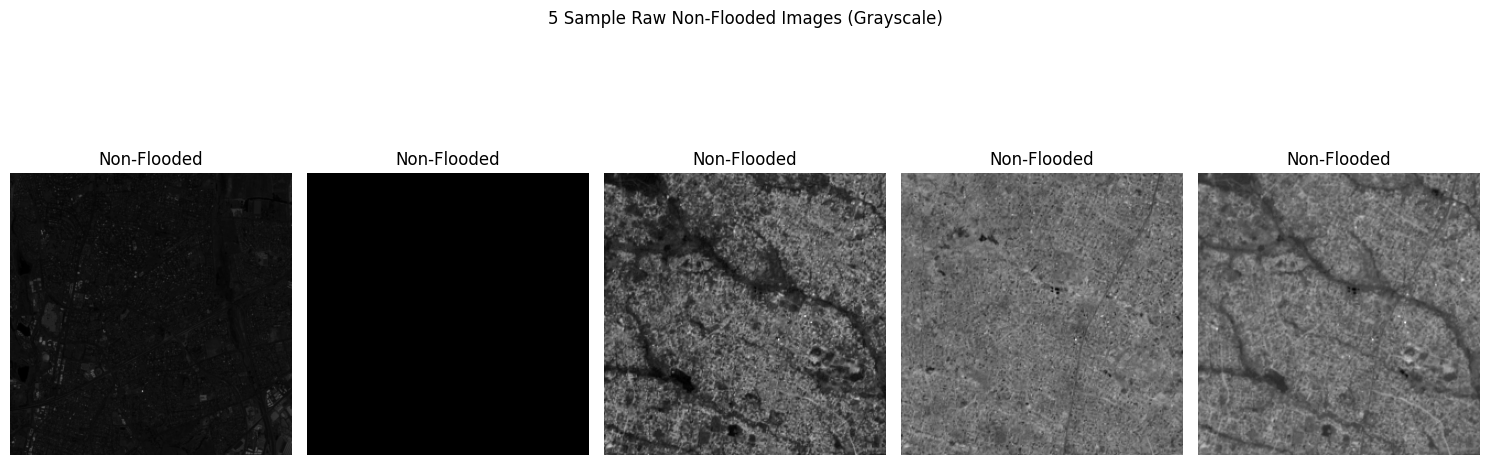

In [ ]:
def load_raw_greyscale_image(image_filepath):
    """
    Reads a TIFF file and returns a grayscale image that is suitable for human interpretation.

    The function:
      - Opens the TIFF file using rasterio.
      - Reads only the first band of the image.
      - Applies a simple min-max stretch to scale pixel values to the range [0, 255].

    Parameters:
      image_filepath (str): The full file path to the TIFF image.

    Returns:
      np.ndarray: A 2D NumPy array (height x width) of type uint8 representing the grayscale image.
    """
    # Open the image file
    with rasterio.open(image_filepath) as src:
        # Read the first band (assumed to contain grayscale data)
        image_data = src.read(1).astype(float)

    # Compute minimum and maximum pixel values
    pixel_min = np.nanmin(image_data)
    pixel_max = np.nanmax(image_data)

    # Apply min-max stretching if possible
    if pixel_max > pixel_min:
        stretched_image = (image_data - pixel_min) / (pixel_max - pixel_min)
    else:
        stretched_image = np.zeros_like(image_data)

    # Scale to 0-255 and convert to uint8
    grayscale_image = (stretched_image * 255).clip(0, 255).astype(np.uint8)

    return grayscale_image

# Assume that 'tif_files' and 'flood_labels' are already defined in previous cells.
# Filter the TIFF files into flooded and non-flooded lists using the flood_labels mapping.
flooded_files = [f for f in tif_files if flood_labels.get(os.path.basename(os.path.dirname(f)), 0) == 1]
non_flooded_files = [f for f in tif_files if flood_labels.get(os.path.basename(os.path.dirname(f)), 0) == 0]

print("Number of flooded images:", len(flooded_files))
print("Number of non-flooded images:", len(non_flooded_files))

# Display 5 sample flooded grayscale images
plt.figure(figsize=(15, 6))
for idx, image_path in enumerate(flooded_files[:5]):
    grayscale_img = load_raw_greyscale_image(image_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(grayscale_img, cmap="gray")
    plt.title("Flooded")
    plt.axis("off")
plt.suptitle("5 Sample Raw Flooded Images (Grayscale)")
plt.tight_layout()
plt.show()

# Display 5 sample non-flooded grayscale images
plt.figure(figsize=(15, 6))
for idx, image_path in enumerate(non_flooded_files[:5]):
    grayscale_img = load_raw_greyscale_image(image_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(grayscale_img, cmap="gray")
    plt.title("Non-Flooded")
    plt.axis("off")
plt.suptitle("5 Sample Raw Non-Flooded Images (Grayscale)")
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import rasterio
import cv2
from PIL import Image
import torch

def is_sentinel1(path: str) -> bool:
    fname = os.path.basename(path)
    return "/S1" in path or fname.startswith("S1")

def is_sentinel2(path: str) -> bool:
    fname = os.path.basename(path)
    return "/S2" in path or fname.startswith("S2")

def speckle_reduce(img: np.ndarray, ksize: int = 5) -> np.ndarray:
    """Median filter to reduce speckle noise (SAR)."""
    return cv2.medianBlur(img.astype(np.uint8), ksize)

def percentile_stretch(band: np.ndarray, pmin: float = 2, pmax: float = 98) -> np.ndarray:
    """Scale band to 0–255 by clipping to [pmin,pmax] percentile then stretching."""
    lo, hi = np.nanpercentile(band, (pmin, pmax))
    band = np.clip(band, lo, hi)
    band = (band - lo) / (hi - lo) if hi > lo else np.zeros_like(band)
    return (band * 255).astype(np.uint8)

def apply_clahe(band: np.ndarray, clip_limit: float = 2.0, tile_grid_size=(8,8)) -> np.ndarray:
    """Apply CLAHE to a single channel."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(band)

In [ ]:
# Define transformations (e.g., resizing, converting to tensor, normalizing)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Adjust size as needed
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Adjust channels if needed
])

def preprocess_image(image_path: str) -> torch.Tensor:
    """
    Sensor‑aware read → enhancement → PIL → existing transform pipeline.
    You can drop this in place of your old preprocess_image and leave the rest of your notebook unchanged.
    """
    # 1) Read raw into bands
    with rasterio.open(image_path) as src:
        cnt = src.count
        if is_sentinel1(image_path):
            arr = src.read(1).astype(float)
            lo, hi = np.nanmin(arr), np.nanmax(arr)
            if hi > lo:
                # safe normalization
                norm = ((arr - lo) / (hi - lo) * 255).astype(np.uint8)
            else:
                # constant image → all zeros
                norm = np.zeros_like(arr, dtype=np.uint8)
            clean = speckle_reduce(norm)
            rgb = np.stack([clean]*3, axis=-1)

        elif is_sentinel2(image_path) and cnt >= 3:
            # assume bands B04=B, B03=G, B02=R ordering in filenames
            # adjust indices if necessary
            r = src.read(4).astype(float) if cnt>=4 else src.read(1).astype(float)
            g = src.read(3).astype(float) if cnt>=3 else src.read(1).astype(float)
            b = src.read(2).astype(float) if cnt>=3 else src.read(1).astype(float)
            # percentile stretch
            r, g, b = percentile_stretch(r), percentile_stretch(g), percentile_stretch(b)
            # CLAHE per channel
            r, g, b = apply_clahe(r), apply_clahe(g), apply_clahe(b)
            rgb = np.stack([r, g, b], axis=-1)
        else:
            # fallback single‐band → 3‐channel gray
            arr = src.read(1).astype(float)
            arr = (arr - arr.min()) / (arr.max() - arr.min()) if arr.max() > arr.min() else np.zeros_like(arr)
            arr = (arr * 255).astype(np.uint8)
            rgb = np.stack([arr]*3, axis=-1)

    # 2) Convert to PIL and hand off to your existing transform
    pil = Image.fromarray(rgb)
    return transform(pil)

def preprocess_image(image_path: str) -> torch.Tensor:
    """
    Sensor‑aware read → enhancement → PIL → existing transform pipeline.
    Falls back to a blank image if anything goes wrong reading the TIFF.
    """
    try:
        with rasterio.open(image_path) as src:
            cnt = src.count

            if is_sentinel1(image_path):
                # ---- Sentinel‑1: band1 → speckle filter → replicate to 3‐ch ----
                arr = src.read(1).astype(float)
                # normalize to 0–255 then median‐filter speckle
                norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
                clean = speckle_reduce(norm)
                rgb = np.stack([clean]*3, axis=-1)

            elif is_sentinel2(image_path) and cnt >= 3:
                # ---- Sentinel‑2: true‐color bands → percentile stretch → CLAHE ----
                # assume at least 4 bands so we can read 4,3,2
                r = src.read(4).astype(float)
                g = src.read(3).astype(float)
                b = src.read(2).astype(float)
                r = apply_clahe(percentile_stretch(r))
                g = apply_clahe(percentile_stretch(g))
                b = apply_clahe(percentile_stretch(b))
                rgb = np.stack([r, g, b], axis=-1)

            else:
                # ---- fallback: single‐band → normalize → replicate ----
                arr = src.read(1).astype(float)
                lo, hi = np.nanmin(arr), np.nanmax(arr)
                if hi > lo:
                    arr = ((arr - lo)/(hi - lo) * 255).astype(np.uint8)
                else:
                    arr = np.zeros_like(arr, dtype=np.uint8)
                rgb = np.stack([arr]*3, axis=-1)

        # Convert to PIL and hand off to your existing `transform`
        pil = Image.fromarray(rgb)
        return transform(pil)

    except Exception as e:

        # return a blank 3×224×224 tensor so your training continues
        return torch.zeros((3, 224, 224))

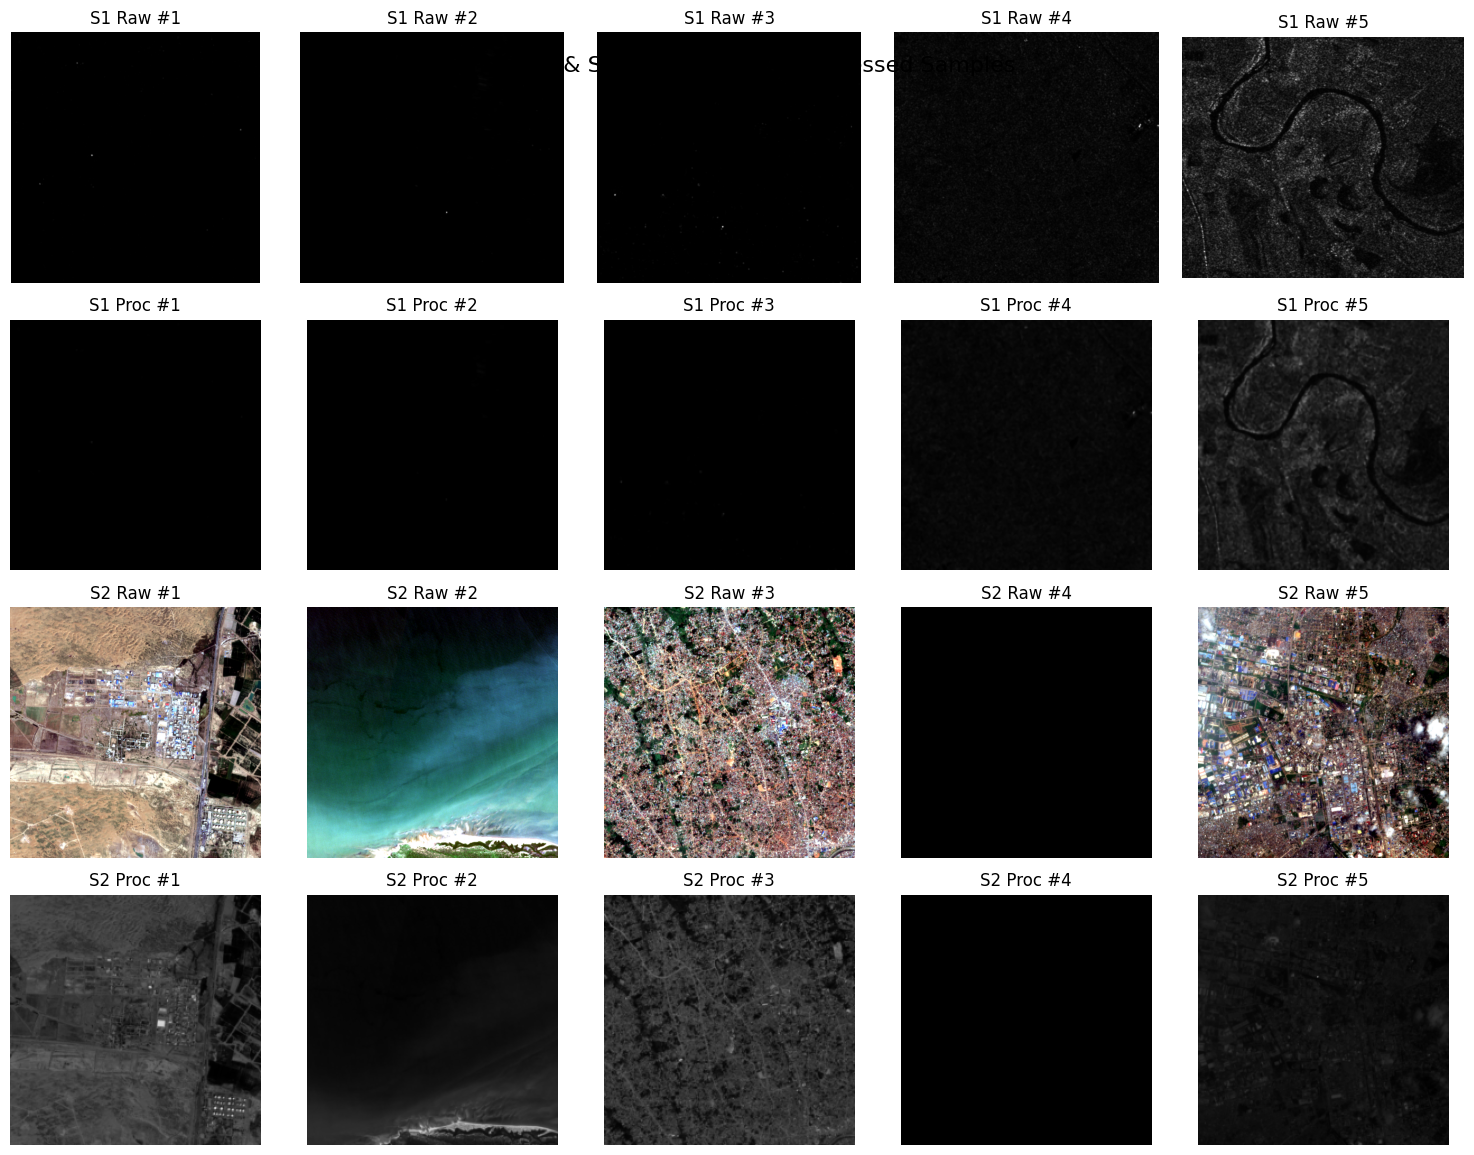

In [ ]:
# %% [code] 5 Raw vs. Processed Samples: Sentinel-1 & Sentinel-2

import random
import matplotlib.pyplot as plt

# Sample 5 random Sentinel-1 and Sentinel-2 scenes
raw_s1 = random.sample(sentinel1_files, 5)
raw_s2 = random.sample(
    [fp for fp in sentinel2_files if fp.endswith('_B04.tif')],
    5
)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

# Row 0: RAW Sentinel-1
for i, fp in enumerate(raw_s1):
    axes[0, i].imshow(load_s1_gray(fp), cmap='gray')
    axes[0, i].set_title(f'S1 Raw #{i+1}')
    axes[0, i].axis('off')

# Row 1: PROCESSED Sentinel-1
for i, fp in enumerate(raw_s1):
    tensor = preprocess_image(fp)
    img = tensor.mul(0.5).add(0.5).permute(1,2,0).cpu().numpy()
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'S1 Proc #{i+1}')
    axes[1, i].axis('off')

# Row 2: RAW Sentinel-2 (True-Color)
for i, fp in enumerate(raw_s2):
    axes[2, i].imshow(load_s2_true_color(fp))
    axes[2, i].set_title(f'S2 Raw #{i+1}')
    axes[2, i].axis('off')

# Row 3: PROCESSED Sentinel-2
for i, fp in enumerate(raw_s2):
    tensor = preprocess_image(fp)
    img = tensor.mul(0.5).add(0.5).permute(1,2,0).cpu().numpy()
    axes[3, i].imshow(img)
    axes[3, i].set_title(f'S2 Proc #{i+1}')
    axes[3, i].axis('off')

plt.suptitle('Sentinel-1 & Sentinel-2: Raw vs Processed Samples', y=0.92, fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
class FloodDataset(Dataset):
    def __init__(self, img_dir, label_map):
        # Recursively gather all .tif images
        self.img_paths = glob.glob(os.path.join(img_dir, "**/*.tif"), recursive=True)
        self.label_map = label_map

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        folder_name = os.path.basename(os.path.dirname(img_path))
        label = self.label_map.get(folder_name, 0)  # Default to 0 if not found
        image = preprocess_image(img_path)
        return image, label

# Instantiate the dataset
dataset = FloodDataset(data_dir, flood_labels)
print(f"Dataset created with {len(dataset)} samples.")

Dataset created with 36053 samples.


In [ ]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Train: 25237, Val: 5407, Test: 5409


In [ ]:
from torch.amp import GradScaler
use_amp = (device.type == "cuda")
scaler = GradScaler(enabled=use_amp)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        ctx = torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp)
        with ctx:
            outputs = model(images)
            if hasattr(outputs, "logits"):  # for ViT
                outputs = outputs.logits
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
                loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# 1. Load and modify ResNet-50
resnet_model = models.resnet50(pretrained=True)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)  # 2 = binary classification
resnet_model = resnet_model.to(device)

# 2. Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.AdamW(resnet_model.parameters(), lr=1e-4)

# 3. Hyperparameters for training
num_epochs = 50
patience = 2
early_stop_threshold = 0.001

log_model_hparams(
    model_name="ResNet50",
    optimizer=optimizer_resnet,
    num_epochs=num_epochs,
    patience=patience,
    early_stop_threshold=early_stop_threshold,
    img_size=224,          # or 256 if your transform uses 256
    batch_size=train_loader.batch_size,
    notes={"pretrained":"torchvision", "loss":"CrossEntropyLoss"}
)


best_val_loss = float('inf')
epochs_no_improve = 0

# Lists to store metrics for plotting
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# 4. Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(resnet_model, train_loader, optimizer_resnet, criterion, device)
    val_loss, val_acc = validate_epoch(resnet_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Early stopping conditions
    if val_loss < early_stop_threshold:
        print("Validation loss is very low; stopping training early.")
        break

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Validation loss did not improve for {patience} epochs; stopping training.")
            break

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


[hparams] logged for ResNet50 -> /kaggle/working/hparams_models.json


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Epoch 1/50
Train Loss: 0.2129 | Train Acc: 0.8967
Val   Loss: 0.1479 | Val   Acc: 0.9231


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

...

Epoch 5/50
Train Loss: 0.0864 | Train Acc: 0.9521
Val   Loss: 0.0898 | Val   Acc: 0.9495


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Epoch 6/50
Train Loss: 0.0766 | Train Acc: 0.9551
Val   Loss: 0.1000 | Val   Acc: 0.9502


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Epoch 7/50
Train Loss: 0.0692 | Train Acc: 0.9583
Val   Loss: 0.1183 | Val   Acc: 0.9462
Validation loss did not improve for 2 epochs; stopping training.


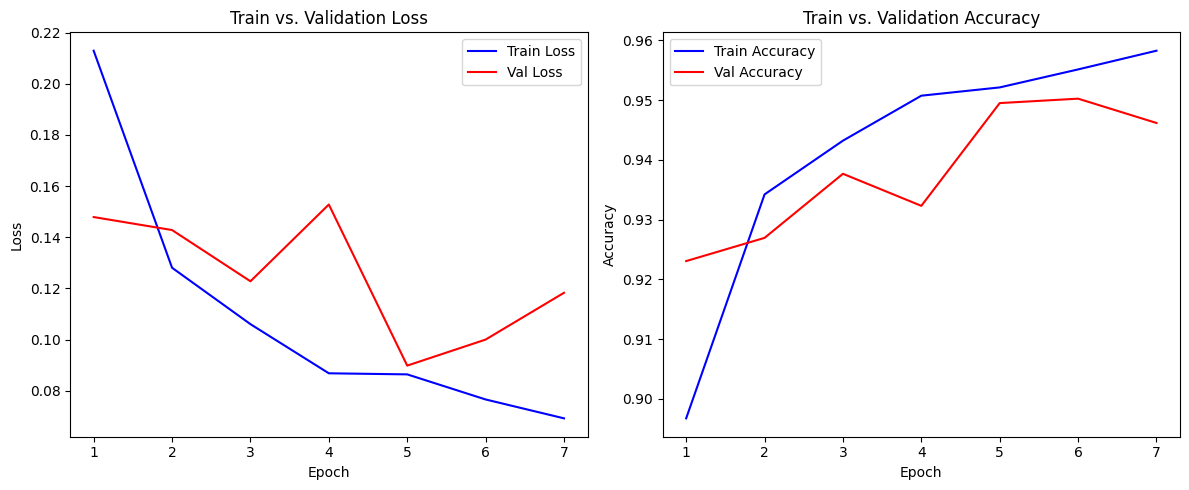

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label="Train Loss")
plt.plot(epochs, val_losses, 'r-', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs. Validation Loss")
plt.legend()

# Plot Training vs Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b-', label="Train Accuracy")
plt.plot(epochs, val_accuracies, 'r-', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs. Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ResNet Test Metrics
Test Accuracy:  0.9458
Test Precision: 0.9472
Test Recall:    0.9458
Test F1-Score: 0.9449

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      1749
           1       0.94      0.99      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.95      0.92      0.94      5409
weighted avg       0.95      0.95      0.94      5409



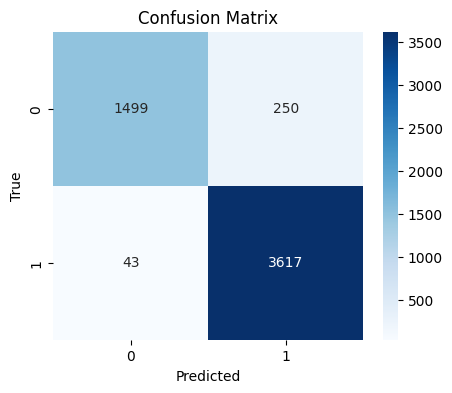

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds)

    return acc, prec, rec, f1, cm, cr

# Evaluate ResNet on test set
acc, prec, rec, f1, cm, cr = evaluate_model(resnet_model, test_loader, device)
print("ResNet Test Metrics")
print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(cr)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import torch

# Save model checkpoint
torch.save(resnet_model.state_dict(), "resnet_model_checkpoint.pth")
print("Model checkpoint saved as 'resnet_model_checkpoint.pth'.")

# Optionally, save training metrics
import pickle

metrics = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accuracies": train_accuracies,
    "val_accuracies": val_accuracies
}

with open("resnet_metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

print("Training metrics saved as 'resnet_metrics.pkl'.")

Model checkpoint saved as 'resnet_model_checkpoint.pth'.
Training metrics saved as 'resnet_metrics.pkl'.


In [ ]:
# Re-create the model architecture
loaded_resnet = models.resnet50(pretrained=False)
loaded_resnet.fc = nn.Linear(loaded_resnet.fc.in_features, 2)

# Load the saved state dict
loaded_resnet.load_state_dict(torch.load("resnet_model_checkpoint.pth"))

# Move to device and set to eval mode
loaded_resnet = loaded_resnet.to(device)
loaded_resnet.eval()

print("Model loaded from 'resnet_model_checkpoint.pth' and set to eval mode.")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from 'resnet_model_checkpoint.pth' and set to eval mode.


<ipython-input-22-e805a381c5f8>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_resnet.load_state_dict(torch.load("resnet_model_checkpoint.pth"))


In [ ]:
# Load pre-trained DenseNet-121 and modify it for binary classification
densenet_model = models.densenet121(pretrained=True)
num_features = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_features, 2)
densenet_model = densenet_model.to(device)
print("DenseNet-121 loaded and modified for binary classification.")

# Create a new optimizer for DenseNet
optimizer_dense = optim.AdamW(densenet_model.parameters(), lr=1e-4)

# Define loss function if not already defined
criterion = nn.CrossEntropyLoss()

# Set hyperparameters for training
num_epochs = 50
patience = 2
early_stop_threshold = 0.001

log_model_hparams(
    model_name="DenseNet121",
    optimizer=optimizer_dense,
    num_epochs=num_epochs,
    patience=patience,
    early_stop_threshold=early_stop_threshold,
    img_size=224,          # or 256, match your transform
    batch_size=train_loader.batch_size,
    notes={"pretrained":"torchvision", "loss":"CrossEntropyLoss"}
)


best_val_loss = float('inf')
epochs_no_improve = 0

# Initialize lists to record training and validation metrics
dense_train_losses, dense_train_accuracies = [], []
dense_val_losses, dense_val_accuracies = [], []

# Training loop for DenseNet
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(densenet_model, train_loader, optimizer_dense, criterion, device)
    val_loss, val_acc = validate_epoch(densenet_model, val_loader, criterion, device)

    dense_train_losses.append(train_loss)
    dense_train_accuracies.append(train_acc)
    dense_val_losses.append(val_loss)
    dense_val_accuracies.append(val_acc)

    print(f"DenseNet - Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping checks
    if val_loss < early_stop_threshold:
        print("Validation loss is negligible; stopping training early.")
        break
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Validation loss did not improve for {patience} consecutive epochs; stopping training.")
            break

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s] 


DenseNet-121 loaded and modified for binary classification.
[hparams] logged for DenseNet121 -> /kaggle/working/hparams_models.json


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

DenseNet - Epoch 1/50
Train Loss: 0.2004 | Train Acc: 0.8992
Val Loss: 0.1735 | Val Acc: 0.9155


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

...

DenseNet - Epoch 4/50
Train Loss: 0.0919 | Train Acc: 0.9492
Val Loss: 0.1033 | Val Acc: 0.9449


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

DenseNet - Epoch 5/50
Train Loss: 0.0790 | Train Acc: 0.9534
Val Loss: 0.1261 | Val Acc: 0.9369


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

DenseNet - Epoch 6/50
Train Loss: 0.0775 | Train Acc: 0.9547
Val Loss: 0.1097 | Val Acc: 0.9486
Validation loss did not improve for 2 consecutive epochs; stopping training.


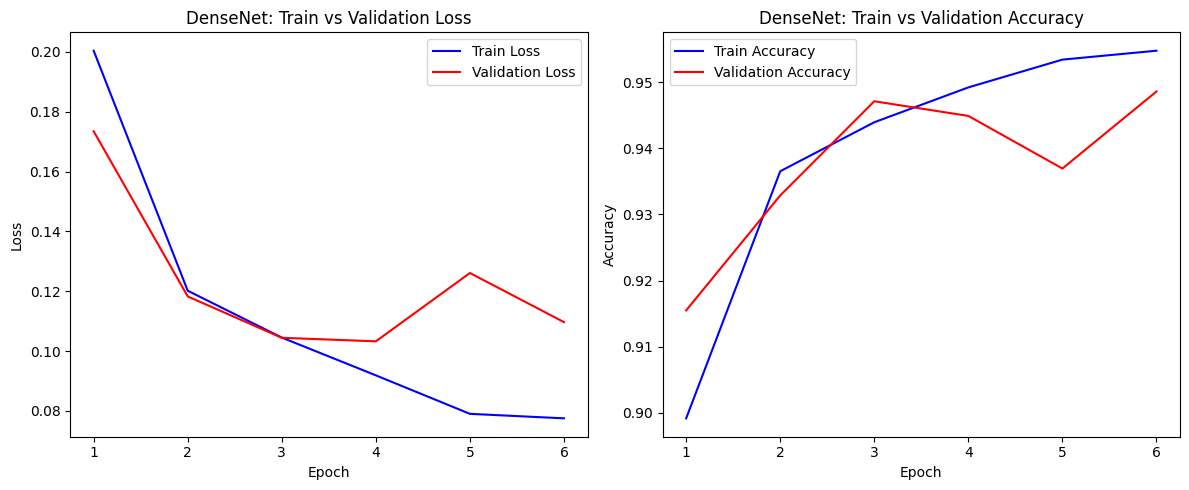

In [ ]:
# Plot Training vs Validation Loss and Accuracy for DenseNet
epochs_range = range(1, len(dense_train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, dense_train_losses, 'b-', label="Train Loss")
plt.plot(epochs_range, dense_val_losses, 'r-', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet: Train vs Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, dense_train_accuracies, 'b-', label="Train Accuracy")
plt.plot(epochs_range, dense_val_accuracies, 'r-', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet: Train vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

DenseNet Test Metrics:
Accuracy:  0.9492
Precision: 0.9504
Recall:    0.9492
F1 Score:  0.9483

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1749
           1       0.94      0.99      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.93      0.94      5409
weighted avg       0.95      0.95      0.95      5409



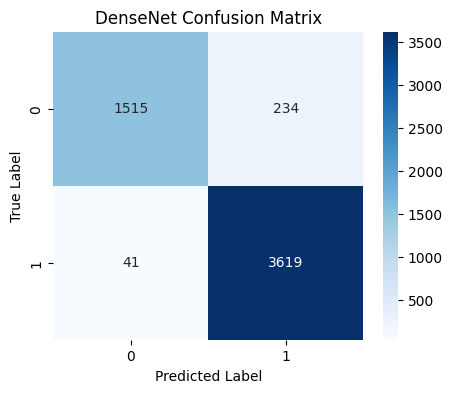

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                # For models like ViT, extract logits if necessary
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds)
    return acc, prec, rec, f1, cm, cr

# Evaluate DenseNet on test set
acc, prec, rec, f1, cm, cr = evaluate_model(densenet_model, test_loader, device)
print("DenseNet Test Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:")
print(cr)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("DenseNet Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Save the DenseNet model checkpoint
torch.save(densenet_model.state_dict(), "densenet_model_checkpoint.pth")
print("DenseNet model checkpoint saved as 'densenet_model_checkpoint.pth'.")

# Save DenseNet training metrics using pickle
dense_metrics = {
    "train_losses": dense_train_losses,
    "train_accuracies": dense_train_accuracies,
    "val_losses": dense_val_losses,
    "val_accuracies": dense_val_accuracies,
    "test_metrics": {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
}

with open("densenet_metrics.pkl", "wb") as f:
    pickle.dump(dense_metrics, f)

print("DenseNet training metrics saved as 'densenet_metrics.pkl'.")

DenseNet model checkpoint saved as 'densenet_model_checkpoint.pth'.
DenseNet training metrics saved as 'densenet_metrics.pkl'.


In [ ]:
# Re-create the DenseNet-121 architecture
loaded_densenet = models.densenet121(pretrained=False)
num_features = loaded_densenet.classifier.in_features
loaded_densenet.classifier = nn.Linear(num_features, 2)

# Load the saved state dictionary (ensure the path matches where you saved it)
loaded_densenet.load_state_dict(torch.load("densenet_model_checkpoint.pth", map_location=device))

# Move the model to the device and set it to evaluation mode
loaded_densenet = loaded_densenet.to(device)
loaded_densenet.eval()

print("DenseNet model loaded from checkpoint and set to eval mode.")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-27-106c56ddd15a>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions

DenseNet model loaded from checkpoint and set to eval mode.


In [ ]:
# Load EfficientNet-B0 using timm and modify for binary classification
efficientnet_model = timm.create_model('efficientnet_b0', pretrained=True)
num_features = efficientnet_model.get_classifier().in_features
efficientnet_model.classifier = nn.Linear(num_features, 2)
efficientnet_model = efficientnet_model.to(device)
print("EfficientNet-B0 loaded and modified for binary classification.")

# Create a new optimizer for EfficientNet
optimizer_eff = optim.AdamW(efficientnet_model.parameters(), lr=1e-4)

# Define loss function (if not defined already)
criterion = nn.CrossEntropyLoss()

# Hyperparameters for training
num_epochs = 50
patience = 2
early_stop_threshold = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

log_model_hparams(
    model_name="EfficientNetB0",
    optimizer=optimizer_eff,
    num_epochs=num_epochs,
    patience=patience,
    early_stop_threshold=early_stop_threshold,
    img_size=224,          # many people use 224 for B0; use 256 if that's your Resize
    batch_size=train_loader.batch_size,
    notes={"pretrained":"timm", "loss":"CrossEntropyLoss"}
)


# Lists to record training and validation metrics
eff_train_losses, eff_train_accuracies = [], []
eff_val_losses, eff_val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(efficientnet_model, train_loader, optimizer_eff, criterion, device)
    val_loss, val_acc = validate_epoch(efficientnet_model, val_loader, criterion, device)

    eff_train_losses.append(train_loss)
    eff_train_accuracies.append(train_acc)
    eff_val_losses.append(val_loss)
    eff_val_accuracies.append(val_acc)

    print(f"EfficientNet - Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < early_stop_threshold:
        print("Validation loss is negligible; stopping training early.")
        break
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Validation loss did not improve for {patience} consecutive epochs; stopping training.")
            break

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0 loaded and modified for binary classification.
[hparams] logged for EfficientNetB0 -> /kaggle/working/hparams_models.json


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

EfficientNet - Epoch 1/50
Train Loss: 0.2093 | Train Acc: 0.8971
Val Loss: 0.1407 | Val Acc: 0.9197


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

...

EfficientNet - Epoch 7/50
Train Loss: 0.0658 | Train Acc: 0.9578
Val Loss: 0.0837 | Val Acc: 0.9564


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

EfficientNet - Epoch 8/50
Train Loss: 0.0629 | Train Acc: 0.9601
Val Loss: 0.0883 | Val Acc: 0.9490


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

EfficientNet - Epoch 9/50
Train Loss: 0.0666 | Train Acc: 0.9569
Val Loss: 0.0958 | Val Acc: 0.9471
Validation loss did not improve for 2 consecutive epochs; stopping training.


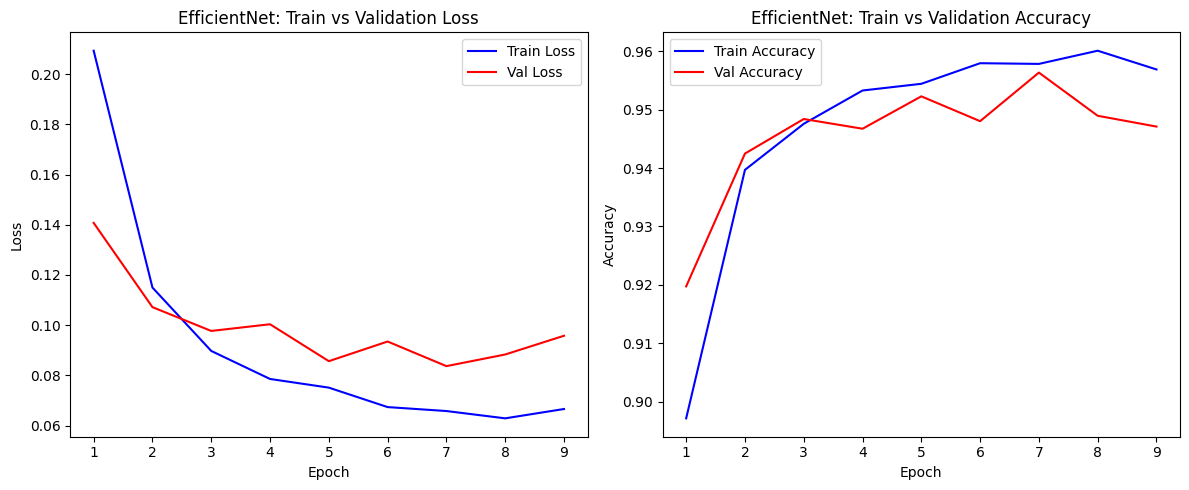

In [ ]:
# Plotting training vs. validation loss and accuracy for EfficientNet
epochs_range = range(1, len(eff_train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, eff_train_losses, 'b-', label="Train Loss")
plt.plot(epochs_range, eff_val_losses, 'r-', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet: Train vs Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, eff_train_accuracies, 'b-', label="Train Accuracy")
plt.plot(epochs_range, eff_val_accuracies, 'r-', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet: Train vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

EfficientNet Test Metrics:
Accuracy:  0.9512
Precision: 0.9567
Recall:    0.9512
F1 Score:  0.9519

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      1749
           1       1.00      0.93      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.93      0.96      0.95      5409
weighted avg       0.96      0.95      0.95      5409



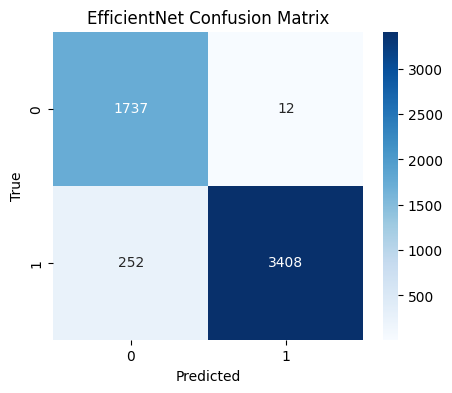

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds)
    return acc, prec, rec, f1, cm, cr

# Evaluate EfficientNet on the test set
eff_acc, eff_prec, eff_rec, eff_f1, eff_cm, eff_cr = evaluate_model(efficientnet_model, test_loader, device)

print("EfficientNet Test Metrics:")
print(f"Accuracy:  {eff_acc:.4f}")
print(f"Precision: {eff_prec:.4f}")
print(f"Recall:    {eff_rec:.4f}")
print(f"F1 Score:  {eff_f1:.4f}")
print("\nClassification Report:")
print(eff_cr)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(eff_cm, annot=True, fmt='d', cmap='Blues')
plt.title("EfficientNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# Save the EfficientNet model checkpoint
torch.save(efficientnet_model.state_dict(), "efficientnet_model_checkpoint.pth")
print("EfficientNet model checkpoint saved as 'efficientnet_model_checkpoint.pth'.")

# Save the training metrics using pickle
eff_metrics_dict = {
    "train_losses": eff_train_losses,
    "train_accuracies": eff_train_accuracies,
    "val_losses": eff_val_losses,
    "val_accuracies": eff_val_accuracies,
    "test_metrics": {"accuracy": eff_acc, "precision": eff_prec, "recall": eff_rec, "f1": eff_f1}
}

with open("efficientnet_metrics.pkl", "wb") as f:
    pickle.dump(eff_metrics_dict, f)

print("EfficientNet training metrics saved as 'efficientnet_metrics.pkl'.")

EfficientNet model checkpoint saved as 'efficientnet_model_checkpoint.pth'.
EfficientNet training metrics saved as 'efficientnet_metrics.pkl'.


In [ ]:
# Code to load the saved EfficientNet model checkpoint
loaded_efficientnet = timm.create_model('efficientnet_b0', pretrained=False)
num_features = loaded_efficientnet.get_classifier().in_features
loaded_efficientnet.classifier = nn.Linear(num_features, 2)
loaded_efficientnet.load_state_dict(torch.load("efficientnet_model_checkpoint.pth", map_location=device))
loaded_efficientnet = loaded_efficientnet.to(device)
loaded_efficientnet.eval()
print("EfficientNet model loaded from checkpoint and set to eval mode.")

EfficientNet model loaded from checkpoint and set to eval mode.


<ipython-input-32-da5fd5cf1eca>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_efficientnet.load_state_dict(torch.load("efficientnet_model_checkpoint.pth", map_loca

In [ ]:
from transformers import ViTForImageClassification
import torch.optim as optim
import torch.nn as nn

# Load pre-trained ViT and modify for binary classification
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2
)
vit_model.to(device)
print("ViT model loaded and modified for binary classification.")

# Create an optimizer for ViT (adjust learning rate as needed)
optimizer_vit = optim.AdamW(vit_model.parameters(), lr=5e-5)

# Define loss function if not defined already
criterion = nn.CrossEntropyLoss()

# Hyperparameters for training
num_epochs = 50
patience = 2
early_stop_threshold = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

log_model_hparams(
    model_name="ViT_B16",
    optimizer=optimizer_vit,
    num_epochs=num_epochs,
    patience=patience,
    early_stop_threshold=early_stop_threshold,
    img_size=224,          # ViT-B/16 usually 224
    batch_size=train_loader.batch_size,
    notes={"pretrained":"transformers", "loss":"CrossEntropyLoss"}
)


# Lists to record training and validation metrics for ViT
vit_train_losses, vit_train_accuracies = [], []
vit_val_losses, vit_val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(vit_model, train_loader, optimizer_vit, criterion, device)
    val_loss, val_acc = validate_epoch(vit_model, val_loader, criterion, device)

    vit_train_losses.append(train_loss)
    vit_train_accuracies.append(train_acc)
    vit_val_losses.append(val_loss)
    vit_val_accuracies.append(val_acc)

    print(f"ViT - Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < early_stop_threshold:
        print("Validation loss is negligible; stopping training early.")
        break
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Validation loss did not improve for {patience} consecutive epochs; stopping training.")
            break

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

ViT - Epoch 4/50
Train Loss: 0.0978 | Train Acc: 0.9430
Val Loss: 0.0974 | Val Acc: 0.9482


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ViT - Epoch 5/50
Train Loss: 0.0893 | Train Acc: 0.9490
Val Loss: 0.1023 | Val Acc: 0.9423


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ViT - Epoch 6/50
Train Loss: 0.0819 | Train Acc: 0.9509
Val Loss: 0.1156 | Val Acc: 0.9423
Validation loss did not improve for 2 consecutive epochs; stopping training.


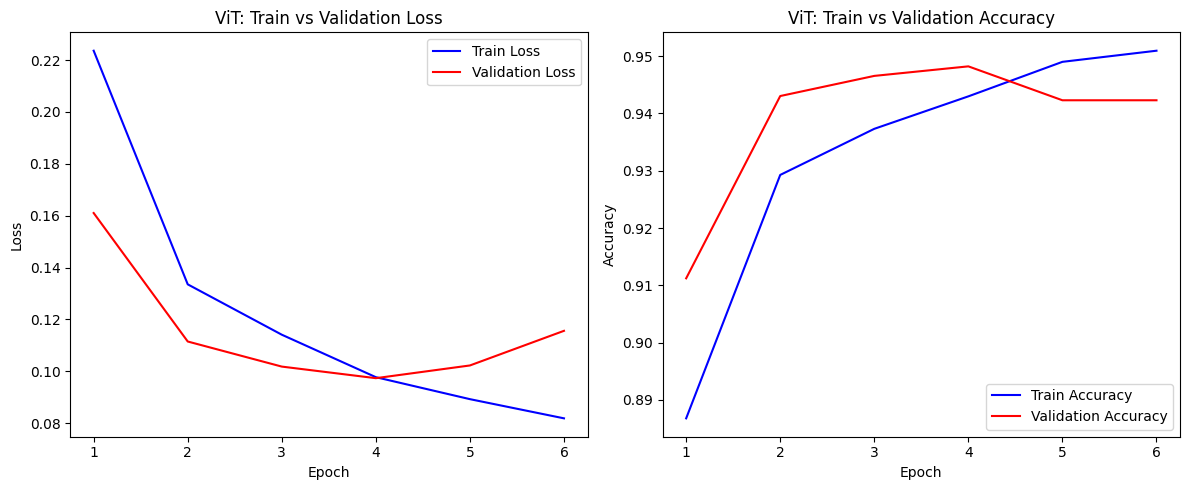

In [ ]:
# Plot training and validation loss and accuracy for ViT
epochs_range = range(1, len(vit_train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, vit_train_losses, 'b-', label="Train Loss")
plt.plot(epochs_range, vit_val_losses, 'r-', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT: Train vs Validation Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, vit_train_accuracies, 'b-', label="Train Accuracy")
plt.plot(epochs_range, vit_val_accuracies, 'r-', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT: Train vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ViT Test Metrics:
Accuracy:  0.9405
Precision: 0.9406
Recall:    0.9405
F1 Score:  0.9398

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1749
           1       0.94      0.97      0.96      3660

    accuracy                           0.94      5409
   macro avg       0.94      0.92      0.93      5409
weighted avg       0.94      0.94      0.94      5409



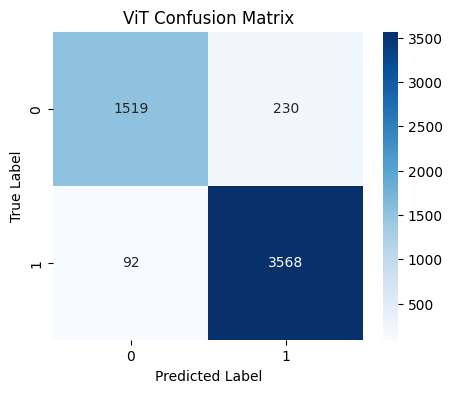

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                # Extract logits if available (ViT returns a structure with logits)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds)
    return acc, prec, rec, f1, cm, cr

# Evaluate ViT on the test set
vit_acc, vit_prec, vit_rec, vit_f1, vit_cm, vit_cr = evaluate_model(vit_model, test_loader, device)

print("ViT Test Metrics:")
print(f"Accuracy:  {vit_acc:.4f}")
print(f"Precision: {vit_prec:.4f}")
print(f"Recall:    {vit_rec:.4f}")
print(f"F1 Score:  {vit_f1:.4f}")
print("\nClassification Report:")
print(vit_cr)

# Plot confusion matrix for ViT
plt.figure(figsize=(5, 4))
sns.heatmap(vit_cm, annot=True, fmt='d', cmap='Blues')
plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Save the ViT model checkpoint
torch.save(vit_model.state_dict(), "vit_model_checkpoint.pth")
print("ViT model checkpoint saved as 'vit_model_checkpoint.pth'.")

# Save the training metrics using pickle
vit_metrics = {
    "train_losses": vit_train_losses,
    "train_accuracies": vit_train_accuracies,
    "val_losses": vit_val_losses,
    "val_accuracies": vit_val_accuracies,
    "test_metrics": {"accuracy": vit_acc, "precision": vit_prec, "recall": vit_rec, "f1": vit_f1}
}

with open("vit_metrics.pkl", "wb") as f:
    pickle.dump(vit_metrics, f)

print("ViT training metrics saved as 'vit_metrics.pkl'.")

ViT model checkpoint saved as 'vit_model_checkpoint.pth'.
ViT training metrics saved as 'vit_metrics.pkl'.


In [ ]:
from transformers import ViTForImageClassification

# Re-create the ViT model architecture
loaded_vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2
)
loaded_vit.load_state_dict(torch.load("vit_model_checkpoint.pth", map_location=device))
loaded_vit = loaded_vit.to(device)
loaded_vit.eval()

print("ViT model loaded from checkpoint and set to eval mode.")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-37-1fbbb0a39fe3>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globa

ViT model loaded from checkpoint and set to eval mode.


In [ ]:
# === FLOPs/Params profiling (one cell) ===
!pip -q install thop >/dev/null
from thop import profile

def profile_model_thop(model, input_size=(1,3,224,224), device=device):
    model = model.to(device).eval()
    x = torch.randn(*input_size, device=device)
    with torch.inference_mode():
        macs, params = profile(model, inputs=(x,), verbose=False)
    return float(params/1e6), float(macs/1e9)  # M params, G MACs/FLOPs-ish

flops_table = {}
# adapt names to your variables as present in that notebook section
for name, mdl in [
    ("ResNet50", loaded_resnet if 'loaded_resnet' in globals() else resnet_model),
    ("DenseNet121", densenet_model if 'densenet_model' in globals() else loaded_densenet),
    ("EffNetB0", efficientnet_model if 'efficientnet_model' in globals() else loaded_efficientnet),
    ("ViT_B16", vit_model if 'vit_model' in globals() else loaded_vit),
]:
    try:
        mparams, gflops = profile_model_thop(mdl, (1,3,224,224), device)
        flops_table[name] = {"params_M": mparams, "FLOPs_G@224": gflops}
    except Exception as e:
        flops_table[name] = {"error": str(e)}

save_json(flops_table, WORKDIR/"flops_params.json")
print(json.dumps(flops_table, indent=2))


{
  "ResNet50": {
    "params_M": 23.51213,
    "FLOPs_G@224": 4.131698688
  },
  "DenseNet121": {
    "params_M": 6.955906,
    "FLOPs_G@224": 2.895985152
  },
  "EffNetB0": {
    "params_M": 3.968094,
    "FLOPs_G@224": 0.384601312
  },
  "ViT_B16": {
    "params_M": 85.64813,
    "FLOPs_G@224": 16.862863872
  }
}


In [ ]:
# === Latency profiling (batch=1) ===
IMG_SIZE = 224  # match your Resize; change if you use 256
latency_table = {}

def time_one(m, name):
    m = m.eval().to(device)
    med, mean, std = torch_inference_latency(m, device, (1,3,IMG_SIZE,IMG_SIZE))
    latency_table[name] = {"gpu_median_ms": med, "gpu_mean_ms": mean, "gpu_std_ms": std}
    m = m.to("cpu")
    medc, meanc, stdc = torch_inference_latency(m, torch.device("cpu"), (1,3,IMG_SIZE,IMG_SIZE))
    latency_table[name].update({"cpu_median_ms": medc, "cpu_mean_ms": meanc, "cpu_std_ms": stdc})

for name, mdl in [
    ("ResNet50", loaded_resnet if 'loaded_resnet' in globals() else resnet_model),
    ("DenseNet121", densenet_model if 'densenet_model' in globals() else loaded_densenet),
    ("EffNetB0", efficientnet_model if 'efficientnet_model' in globals() else loaded_efficientnet),
    ("ViT_B16", vit_model if 'vit_model' in globals() else loaded_vit),
]:
    try: time_one(mdl, name)
    except Exception as e: latency_table[name] = {"error": str(e)}

save_json(latency_table, WORKDIR/"latency.json")
print(json.dumps(latency_table, indent=2))


{
  "ResNet50": {
    "gpu_median_ms": 6.2528005000785924,
    "gpu_mean_ms": 6.274740255003053,
    "gpu_std_ms": 0.18713648535521596,
    "cpu_median_ms": 75.29603050033984,
    "cpu_mean_ms": 75.99590922999596,
    "cpu_std_ms": 4.244360574536633
  },
  "DenseNet121": {
    "gpu_median_ms": 15.477667000141082,
    "gpu_mean_ms": 15.539837510018515,
    "gpu_std_ms": 0.5861730331512246,
    "cpu_median_ms": 82.43128849971981,
    "cpu_mean_ms": 83.04280709999603,
    "cpu_std_ms": 3.672270583621517
  },
  "EffNetB0": {
    "gpu_median_ms": 8.471843999814155,
    "gpu_mean_ms": 8.531863689995589,
    "gpu_std_ms": 0.2635192870559998,
    "cpu_median_ms": 35.071271999640885,
    "cpu_mean_ms": 35.407645094987856,
    "cpu_std_ms": 2.573906776437001
  },
  "ViT_B16": {
    "gpu_median_ms": 15.471854999759671,
    "gpu_mean_ms": 15.448001474969715,
    "gpu_std_ms": 0.30319633584903316,
    "cpu_median_ms": 211.24233049977192,
    "cpu_mean_ms": 212.7139263050367,
    "cpu_std_ms": 7.036

In [ ]:
# === Save per-model probabilities on the test set (FIXED: ensure models on device) ===
from collections import OrderedDict
import numpy as np
import torch

models_for_eval = OrderedDict()
models_for_eval["ResNet50"]    = loaded_resnet if 'loaded_resnet' in globals() else resnet_model
models_for_eval["DenseNet121"] = densenet_model if 'densenet_model' in globals() else loaded_densenet
models_for_eval["EffNetB0"]    = efficientnet_model if 'efficientnet_model' in globals() else loaded_efficientnet
models_for_eval["ViT_B16"]     = vit_model if 'vit_model' in globals() else loaded_vit

# IMPORTANT: move every model back to the active device and set eval()
for name, mdl in models_for_eval.items():
    mdl.to(device)
    mdl.eval()

y_true_list = []
per_model_probs = {k: [] for k in models_for_eval.keys()}

use_amp = (device.type == "cuda")  # same flag you used in training

with torch.inference_mode():
    for images, labels in test_loader:
        y_true_list.extend(labels.cpu().numpy().tolist())  # keep labels on CPU for np ops
        images = images.to(device, non_blocking=True)

        # autocast (CUDA only) is fine for forward; harmless if disabled
        ctx = torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp)
        with ctx:
            for name, mdl in models_for_eval.items():
                out = mdl(images)
                if hasattr(out, "logits"):  # ViTForImageClassification
                    out = out.logits
                probs = torch.softmax(out, dim=1).detach().cpu().numpy()
                per_model_probs[name].append(probs)

y_true = np.array(y_true_list)
for k in per_model_probs:
    per_model_probs[k] = np.concatenate(per_model_probs[k], axis=0)  # (N, 2)

np.save(WORKDIR/"y_true.npy", y_true)
np.savez(WORKDIR/"per_model_probs.npz", **per_model_probs)
print("Saved: y_true.npy, per_model_probs.npz")


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Saved: y_true.npy, per_model_probs.npz


In [ ]:
# === 95% bootstrap CIs for Acc/Prec/Rec/F1 ===
y_true = np.load(WORKDIR/"y_true.npy")
probs = np.load(WORKDIR/"per_model_probs.npz")

ci_table = {}
for name in probs.files:
    yhat = probs[name].argmax(1)
    ci = bootstrap_ci_binary(y_true, yhat, n_boot=1000, seed=123)
    ci_table[name] = {
        "acc_mean": ci["acc"][0], "acc_ci": ci["acc"][1],
        "prec_mean": ci["prec"][0], "prec_ci": ci["prec"][1],
        "rec_mean": ci["rec"][0], "rec_ci": ci["rec"][1],
        "f1_mean": ci["f1"][0], "f1_ci": ci["f1"][1],
    }

# Soft-vote ensemble (no retrain) to report as “Ensemble (soft vote)”
stack = np.mean([probs[n] for n in probs.files], axis=0)
yhat = stack.argmax(1)
ci = bootstrap_ci_binary(y_true, yhat, n_boot=1000, seed=123)
ci_table["Ensemble_softvote"] = {
    "acc_mean": ci["acc"][0], "acc_ci": ci["acc"][1],
    "prec_mean": ci["prec"][0], "prec_ci": ci["prec"][1],
    "rec_mean": ci["rec"][0], "rec_ci": ci["rec"][1],
    "f1_mean": ci["f1"][0], "f1_ci": ci["f1"][1],
}

save_json(ci_table, WORKDIR/"bootstrap_cis.json")
print(json.dumps(ci_table, indent=2))


{
  "ResNet50": {
    "acc_mean": 0.9457045664633018,
    "acc_ci": [
      0.9397300794971344,
      0.9517470881863561
    ],
    "prec_mean": 0.9351010811982228,
    "prec_ci": [
      0.9279408425869976,
      0.9427464267850918
    ],
    "rec_mean": 0.9883028585759214,
    "rec_ci": [
      0.9845695517654436,
      0.9916695423567952
    ],
    "f1_mean": 0.9609613881903445,
    "f1_ci": [
      0.9566255761995738,
      0.9653708651538955
    ]
  },
  "DenseNet121": {
    "acc_mean": 0.9489892771307081,
    "acc_ci": [
      0.9434276206322796,
      0.9548899981512294
    ],
    "prec_mean": 0.9390060937740181,
    "prec_ci": [
      0.932023473961462,
      0.946435730914197
    ],
    "rec_mean": 0.9887964235915712,
    "rec_ci": [
      0.9852459016393442,
      0.9921162940119771
    ],
    "f1_mean": 0.9632538418007989,
    "f1_ci": [
      0.9592221745958446,
      0.9675577862170746
    ]
  },
  "EffNetB0": {
    "acc_mean": 0.9511937511554815,
    "acc_ci": [
      0.9

In [ ]:
# === Sequential ablation: add models one-by-one by single-model F1 rank ===
from sklearn.metrics import f1_score
probs = np.load(WORKDIR/"per_model_probs.npz"); y_true = np.load(WORKDIR/"y_true.npy")

rank = sorted([(n, f1_score(y_true, probs[n].argmax(1))) for n in probs.files],
              key=lambda t: t[1], reverse=True)
order = [n for n,_ in rank]

seq_table = []; running = None
for k, name in enumerate(order, start=1):
    running = probs[name] if running is None else (running*(k-1) + probs[name]) / k
    yhat = running.argmax(1)
    seq_table.append({"k": k, "add": name, "F1": float(f1_score(y_true, yhat))})

save_json({"order": order, "seq_table": seq_table}, WORKDIR/"sequential_ablation.json")
print(json.dumps({"order": order, "seq_table": seq_table}, indent=2))


{
  "order": [
    "DenseNet121",
    "EffNetB0",
    "ResNet50",
    "ViT_B16"
  ],
  "seq_table": [
    {
      "k": 1,
      "add": "DenseNet121",
      "F1": 0.9633967789165446
    },
    {
      "k": 2,
      "add": "EffNetB0",
      "F1": 0.9673463947754232
    },
    {
      "k": 3,
      "add": "ResNet50",
      "F1": 0.9673724863497136
    },
    {
      "k": 4,
      "add": "ViT_B16",
      "F1": 0.9676215856095935
    }
  ]
}


In [ ]:
def get_hard_predictions(model, dataloader):
    """
    Returns a list of predicted classes (0 or 1) for all samples in the dataloader.
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                # If the model returns an object with logits (like ViT), extract it.
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            # Get the predicted class
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy())
    return predictions

# Get hard predictions from each model (assuming your models are loaded and in eval mode)
resnet_preds = get_hard_predictions(loaded_resnet, test_loader)
dense_preds  = get_hard_predictions(loaded_densenet, test_loader)
eff_preds    = get_hard_predictions(loaded_efficientnet, test_loader)
vit_preds    = get_hard_predictions(loaded_vit, test_loader)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Ensemble (Hard Voting) Test Metrics:
Accuracy:  0.9506
Precision: 0.9512
Recall:    0.9506
F1 Score:  0.9500

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      1749
           1       0.95      0.98      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.95      0.93      0.94      5409
weighted avg       0.95      0.95      0.95      5409



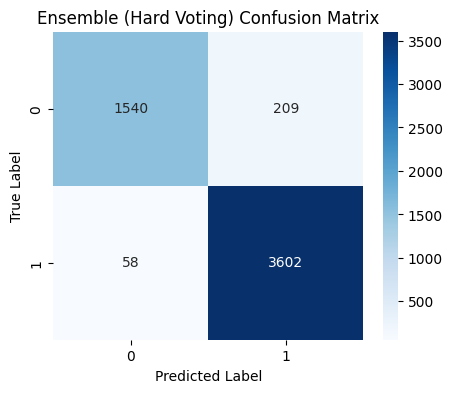

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Combine hard predictions using majority voting
ensemble_hard_preds = []
# Zip predictions from all models
for r, d, e, v in zip(resnet_preds, dense_preds, eff_preds, vit_preds):
    votes = [r, d, e, v]
    # Majority vote: if tie, you can choose a default (here, we'll use max() over count)
    ensemble_hard_preds.append(max(set(votes), key=votes.count))

# Get true labels from the test set
true_labels = []
for _, labels in test_loader:
    true_labels.extend(labels.cpu().numpy())

# Evaluate ensemble with hard voting
acc_hard = accuracy_score(true_labels, ensemble_hard_preds)
prec_hard = precision_score(true_labels, ensemble_hard_preds, average='weighted')
rec_hard = recall_score(true_labels, ensemble_hard_preds, average='weighted')
f1_hard = f1_score(true_labels, ensemble_hard_preds, average='weighted')
cm_hard = confusion_matrix(true_labels, ensemble_hard_preds)
cr_hard = classification_report(true_labels, ensemble_hard_preds)

print("Ensemble (Hard Voting) Test Metrics:")
print(f"Accuracy:  {acc_hard:.4f}")
print(f"Precision: {prec_hard:.4f}")
print(f"Recall:    {rec_hard:.4f}")
print(f"F1 Score:  {f1_hard:.4f}")
print("\nClassification Report:")
print(cr_hard)

# Plot confusion matrix for hard voting ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Blues')
plt.title("Ensemble (Hard Voting) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
def get_probabilities(model, dataloader):
    """
    Returns a numpy array of probability distributions for each sample.
    Each row corresponds to a sample and contains probabilities for each class.
    """
    model.eval()
    probabilities = []
    softmax = nn.Softmax(dim=1)
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            # Convert logits to probabilities
            probs = softmax(outputs)
            probabilities.extend(probs.cpu().numpy())
    return np.array(probabilities)

# Get probability outputs from each model
resnet_probs = get_probabilities(loaded_resnet, test_loader)
dense_probs  = get_probabilities(loaded_densenet, test_loader)
eff_probs    = get_probabilities(loaded_efficientnet, test_loader)
vit_probs    = get_probabilities(loaded_vit, test_loader)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Ensemble (Soft Voting) Test Metrics:
Accuracy:  0.9551
Precision: 0.9563
Recall:    0.9551
F1 Score:  0.9544

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1749
           1       0.94      0.99      0.97      3660

    accuracy                           0.96      5409
   macro avg       0.96      0.93      0.95      5409
weighted avg       0.96      0.96      0.95      5409



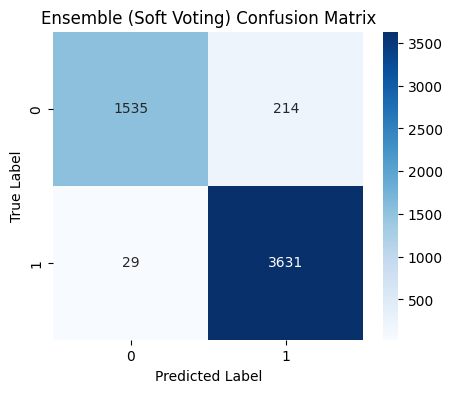

In [ ]:
# Average the probability outputs from each model (soft voting)
ensemble_probs = (resnet_probs + dense_probs + eff_probs + vit_probs) / 4.0
ensemble_soft_preds = np.argmax(ensemble_probs, axis=1)

# Evaluate ensemble with soft voting
acc_soft = accuracy_score(true_labels, ensemble_soft_preds)
prec_soft = precision_score(true_labels, ensemble_soft_preds, average='weighted')
rec_soft = recall_score(true_labels, ensemble_soft_preds, average='weighted')
f1_soft = f1_score(true_labels, ensemble_soft_preds, average='weighted')
cm_soft = confusion_matrix(true_labels, ensemble_soft_preds)
cr_soft = classification_report(true_labels, ensemble_soft_preds)

print("Ensemble (Soft Voting) Test Metrics:")
print(f"Accuracy:  {acc_soft:.4f}")
print(f"Precision: {prec_soft:.4f}")
print(f"Recall:    {rec_soft:.4f}")
print(f"F1 Score:  {f1_soft:.4f}")
print("\nClassification Report:")
print(cr_soft)

# Plot confusion matrix for soft voting ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues')
plt.title("Ensemble (Soft Voting) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
ensemble_metrics = {
    "hard": {
        "accuracy": acc_hard,
        "precision": prec_hard,
        "recall": rec_hard,
        "f1": f1_hard,
        "confusion_matrix": cm_hard.tolist(),  # convert to list for saving as JSON if needed
        "classification_report": cr_hard
    },
    "soft": {
        "accuracy": acc_soft,
        "precision": prec_soft,
        "recall": rec_soft,
        "f1": f1_soft,
        "confusion_matrix": cm_soft.tolist(),
        "classification_report": cr_soft
    }
}

with open("ensemble_metrics.pkl", "wb") as f:
    pickle.dump(ensemble_metrics, f)

print("Ensemble metrics saved as 'ensemble_metrics.pkl'.")

Ensemble metrics saved as 'ensemble_metrics.pkl'.


In [ ]:
import numpy as np
import torch.nn as nn

def get_probabilities(model, dataloader):
    """
    Returns a numpy array of probability outputs for each sample in the dataloader.
    Each row is a probability vector for each class.
    """
    model.eval()
    probabilities = []
    softmax = nn.Softmax(dim=1)
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
            probs = softmax(outputs)
            probabilities.extend(probs.cpu().numpy())
    return np.array(probabilities)

# Generate meta-features for validation set from each base model
val_probs_resnet = get_probabilities(loaded_resnet, val_loader)
val_probs_dense  = get_probabilities(loaded_densenet, val_loader)
val_probs_eff    = get_probabilities(loaded_efficientnet, val_loader)
val_probs_vit    = get_probabilities(loaded_vit, val_loader)

# Stack the probabilities horizontally to form the meta-feature matrix
# For binary classification, each model gives 2 columns; total columns = 4 * 2 = 8
meta_features_val = np.hstack([val_probs_resnet, val_probs_dense, val_probs_eff, val_probs_vit])

# Get the true labels from the validation set
true_val_labels = []
for _, labels in val_loader:
    true_val_labels.extend(labels.cpu().numpy())
true_val_labels = np.array(true_val_labels)

print("Meta-features for validation set shape:", meta_features_val.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Meta-features for validation set shape: (5407, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the meta-model; you can adjust hyperparameters as needed
meta_model = LogisticRegression(max_iter=1000)

# Train the meta-model using the meta-features from the validation set and true labels
meta_model.fit(meta_features_val, true_val_labels)
print("Meta-model (Logistic Regression) trained on validation meta-features.")

Meta-model (Logistic Regression) trained on validation meta-features.


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Stacking Ensemble (Meta-model) Test Metrics:
Accuracy:  0.9554
Precision: 0.9566
Recall:    0.9554
F1 Score:  0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1749
           1       0.95      0.99      0.97      3660

    accuracy                           0.96      5409
   macro avg       0.96      0.94      0.95      5409
weighted avg       0.96      0.96      0.95      5409



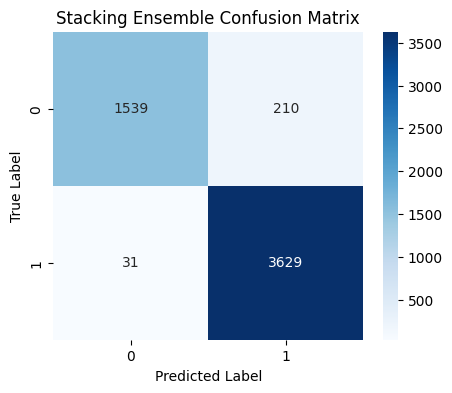

In [ ]:
# Generate meta-features for the test set using the same base models
test_probs_resnet = get_probabilities(loaded_resnet, test_loader)
test_probs_dense  = get_probabilities(loaded_densenet, test_loader)
test_probs_eff    = get_probabilities(loaded_efficientnet, test_loader)
test_probs_vit    = get_probabilities(loaded_vit, test_loader)

meta_features_test = np.hstack([test_probs_resnet, test_probs_dense, test_probs_eff, test_probs_vit])

# Use the trained meta-model to predict final class labels on the test set
stacked_preds = meta_model.predict(meta_features_test)

# Gather true test labels
true_test_labels = []
for _, labels in test_loader:
    true_test_labels.extend(labels.cpu().numpy())
true_test_labels = np.array(true_test_labels)

# Evaluate the stacking ensemble
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_stack = accuracy_score(true_test_labels, stacked_preds)
prec_stack = precision_score(true_test_labels, stacked_preds, average='weighted')
rec_stack = recall_score(true_test_labels, stacked_preds, average='weighted')
f1_stack = f1_score(true_test_labels, stacked_preds, average='weighted')
cm_stack = confusion_matrix(true_test_labels, stacked_preds)
cr_stack = classification_report(true_test_labels, stacked_preds)

print("Stacking Ensemble (Meta-model) Test Metrics:")
print(f"Accuracy:  {acc_stack:.4f}")
print(f"Precision: {prec_stack:.4f}")
print(f"Recall:    {rec_stack:.4f}")
print(f"F1 Score:  {f1_stack:.4f}")
print("\nClassification Report:")
print(cr_stack)

# Plot the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues')
plt.title("Stacking Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import pickle

# Save the trained meta-model for future use
with open("meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("Meta-model saved as 'meta_model.pkl'.")

Meta-model saved as 'meta_model.pkl'.


XGBoost meta-model trained on validation meta-features.
XGBoost Meta-Model Ensemble Test Metrics:
Accuracy:  0.9551
Precision: 0.9567
Recall:    0.9551
F1 Score:  0.9543

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1749
           1       0.94      0.99      0.97      3660

    accuracy                           0.96      5409
   macro avg       0.96      0.93      0.95      5409
weighted avg       0.96      0.96      0.95      5409



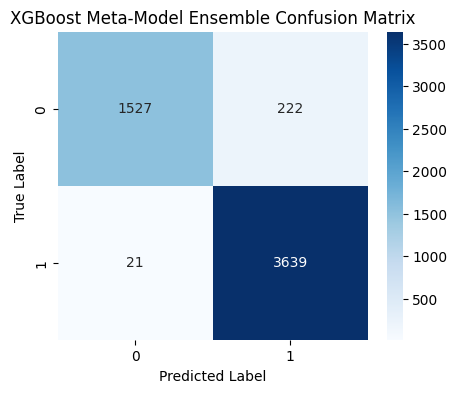

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost classifier as meta-model
meta_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train the XGBoost meta-model on validation meta-features
meta_xgb.fit(meta_features_val, true_val_labels)
print("XGBoost meta-model trained on validation meta-features.")

# Predict on test meta-features using XGBoost
xgb_preds = meta_xgb.predict(meta_features_test)

# Evaluate XGBoost meta-model
acc_xgb = accuracy_score(true_test_labels, xgb_preds)
prec_xgb = precision_score(true_test_labels, xgb_preds, average='weighted')
rec_xgb = recall_score(true_test_labels, xgb_preds, average='weighted')
f1_xgb = f1_score(true_test_labels, xgb_preds, average='weighted')
cm_xgb = confusion_matrix(true_test_labels, xgb_preds)
cr_xgb = classification_report(true_test_labels, xgb_preds)

print("XGBoost Meta-Model Ensemble Test Metrics:")
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print("\nClassification Report:")
print(cr_xgb)

# Plot confusion matrix for XGBoost meta-model ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Meta-Model Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import pickle

# Save the XGBoost meta-model to a file
with open("xgb_meta_model.pkl", "wb") as f:
    pickle.dump(meta_xgb, f)

print("XGBoost meta-model saved as 'xgb_meta_model.pkl'.")

XGBoost meta-model saved as 'xgb_meta_model.pkl'.


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1) Generate probability outputs on the validation set for each base model
resnet_val_probs      = get_probabilities(loaded_resnet, val_loader)
densenet_val_probs    = get_probabilities(loaded_densenet, val_loader)
efficientnet_val_probs= get_probabilities(loaded_efficientnet, val_loader)
vit_val_probs         = get_probabilities(loaded_vit, val_loader)

# 2) Concatenate them horizontally to form your meta‑features
#    Each array is shape (num_val_samples, 2) so final shape is (num_val_samples, 8)
stack_X_val = np.hstack([
    resnet_val_probs,
    densenet_val_probs,
    efficientnet_val_probs,
    vit_val_probs
])

stack_y_val = true_val_labels  # shape (num_val_samples,)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate test‐set probabilities
resnet_test_probs       = get_probabilities(loaded_resnet, test_loader)
densenet_test_probs     = get_probabilities(loaded_densenet, test_loader)
efficientnet_test_probs = get_probabilities(loaded_efficientnet, test_loader)
vit_test_probs          = get_probabilities(loaded_vit, test_loader)

# 2. Stack into test meta‐features (N_test × 8)
stack_X_test = np.hstack([
    resnet_test_probs,
    densenet_test_probs,
    efficientnet_test_probs,
    vit_test_probs
])



<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

In [ ]:
# Cell: Train an SVM meta‐model on the validation meta‑features
from sklearn.svm import SVC

# Initialize SVM with RBF kernel (enable probability estimates if you need soft voting later)
svm_meta = SVC(kernel='rbf', probability=True, random_state=42)

# Fit on the stacked validation features and labels
svm_meta.fit(stack_X_val, stack_y_val)

print("✅ SVM meta‑model trained on validation meta‑features.")

✅ SVM meta‑model trained on validation meta‑features.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_predictions(true_labels, preds, ensemble_name="Ensemble"):
    acc = accuracy_score(true_labels, preds)
    prec = precision_score(true_labels, preds, average='weighted')
    rec = recall_score(true_labels, preds, average='weighted')
    f1 = f1_score(true_labels, preds, average='weighted')
    print(f"{ensemble_name} Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(true_labels, preds))
    cm = confusion_matrix(true_labels, preds)
    return cm

Stacking Ensemble (SVM Meta‑Model) Metrics:
Accuracy:  0.9560
Precision: 0.9573
Recall:    0.9560
F1 Score:  0.9553

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1749
           1       0.95      0.99      0.97      3660

    accuracy                           0.96      5409
   macro avg       0.96      0.94      0.95      5409
weighted avg       0.96      0.96      0.96      5409



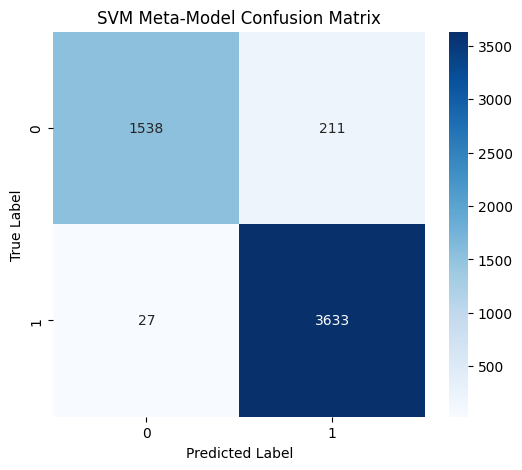

In [ ]:
# Cell: Evaluate the SVM meta‐model on the test set
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test meta‑features
svm_preds = svm_meta.predict(stack_X_test)

# Use the existing helper to print metrics
cm_svm = evaluate_predictions(true_test_labels, svm_preds, "Stacking Ensemble (SVM Meta‑Model)")

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap="Blues")
plt.title("SVM Meta‑Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# === Log meta-learner configs ===
meta_info = {}
try: meta_info["LogReg"] = meta_model.get_params()
except: pass
try: meta_info["XGBClassifier"] = meta_xgb.get_params()
except: pass
try: meta_info["SVM"] = svm_meta.get_params()
except: pass
save_json(meta_info, WORKDIR/"meta_learners_params.json")
print(json.dumps(meta_info, indent=2))


{
  "LogReg": {
    "C": 1.0,
    "class_weight": null,
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": null,
    "max_iter": 1000,
    "multi_class": "auto",
    "n_jobs": null,
    "penalty": "l2",
    "random_state": null,
    "solver": "lbfgs",
    "tol": 0.0001,
    "verbose": 0,
    "warm_start": false
  },
  "XGBClassifier": {
    "objective": "binary:logistic",
    "base_score": null,
    "booster": null,
    "callbacks": null,
    "colsample_bylevel": null,
    "colsample_bynode": null,
    "colsample_bytree": null,
    "device": null,
    "early_stopping_rounds": null,
    "enable_categorical": false,
    "eval_metric": "logloss",
    "feature_types": null,
    "gamma": null,
    "grow_policy": null,
    "importance_type": null,
    "interaction_constraints": null,
    "learning_rate": null,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": null,
    "max_depth": null,
    "max_le

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Set device: GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-create the ResNet-50 architecture and modify its final layer for binary classification
resnet_model = models.resnet50(pretrained=False)  # pretrained is False; we will load our checkpoint
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)  # binary classification (2 classes)
resnet_model = resnet_model.to(device)

# Load the saved checkpoint (ensure the file is in your working directory)
checkpoint_path = "resnet_model_checkpoint.pth"
resnet_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

# Set the model to evaluation mode (important for layers like batchnorm and dropout)
resnet_model.eval()
print("ResNet model loaded from checkpoint and set to eval mode.")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet model loaded from checkpoint and set to eval mode.


<ipython-input-70-b3f6a1c83585>:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_model.load_state_dict(torch.load(checkpoint_path, map_location=device))


In [ ]:
def get_resnet_intermediate_features(model, dataloader):
    """
    Extracts intermediate features from the penultimate layer of ResNet using a forward hook.
    For ResNet-50, we hook into the 'avgpool' layer.

    Returns:
      A numpy array of shape (num_samples, feature_dim) where feature_dim is the number of features.
    """
    model.eval()  # Ensure model is in evaluation mode
    features = []
    hook_outputs = []

    # Define hook function to capture output of the target layer
    def hook_fn(module, input, output):
        hook_outputs.append(output.detach())

    # Register hook on ResNet's average pooling layer
    handle = model.avgpool.register_forward_hook(hook_fn)

    # Loop over the dataloader and collect features
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)  # Forward pass triggers hook
            # hook_outputs is a list of outputs for this batch; typically one tensor per batch
            # For ResNet, avgpool outputs shape (batch, feature_dim, 1, 1); squeeze to get (batch, feature_dim)
            batch_features = hook_outputs[0].squeeze()
            # If batch_features becomes 1D when batch size is 1, unsqueeze it
            if batch_features.dim() == 1:
                batch_features = batch_features.unsqueeze(0)
            features.append(batch_features.cpu())
            hook_outputs.clear()  # Clear hook outputs for next iteration

    # Remove the hook
    handle.remove()
    # Concatenate all batch features into one tensor and convert to numpy array
    features_tensor = torch.cat(features, dim=0)
    return features_tensor.numpy()

# Example: Extract intermediate features for the validation set
# (Assume you already have 'val_loader' defined from your dataset split)
resnet_features_val = get_resnet_intermediate_features(resnet_model, val_loader)
resnet_features_test = get_resnet_intermediate_features(resnet_model, test_loader)

print("ResNet intermediate features for validation set shape:", resnet_features_val.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ResNet intermediate features for validation set shape: (5407, 2048)


In [ ]:
import numpy as np

def reshape_features_to_meta_image(features, new_shape):
    """
    Reshape a 2D numpy array 'features' of shape (num_samples, F) into
    a 4D array of shape (num_samples, 1, H, W), where H*W = F.
    For example, if F=2048, new_shape can be (4, 512).
    """
    num_samples, F = features.shape
    # Ensure the product of new_shape equals F
    assert np.prod(new_shape) == F, "Product of new_shape must equal the number of features."
    # Reshape each feature vector
    meta_images = features.reshape(num_samples, *new_shape)
    # Add channel dimension (here, channel=1)
    meta_images = np.expand_dims(meta_images, axis=1)
    return meta_images

# Reshape the features for validation and test sets
resnet_meta_features_val = reshape_features_to_meta_image(resnet_features_val, (4, 512))
resnet_meta_features_test = reshape_features_to_meta_image(resnet_features_test, (4, 512))

print("Meta-images for validation set shape:", meta_features_val.shape)
print("Meta-images for test set shape:", meta_features_test.shape)

Meta-images for validation set shape: (5407, 8)
Meta-images for test set shape: (5409, 8)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResNetMetaCNN(nn.Module):
    def __init__(self):
        super(ResNetMetaCNN, self).__init__()
        # Input shape: (batch, 1, 4, 512)
        # We'll use a convolutional layer to capture local patterns over the 4 model rows and feature dimension.
        # Here, kernel_size=(2,16) is an example—adjust as needed.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2, 16), stride=1)
        # After conv1, the output shape will be:
        # Height: 4 - 2 + 1 = 3; Width: 512 - 16 + 1 = 497; with 8 channels → (batch, 8, 3, 497)
        # Next, we use a max pooling layer to reduce the width (feature dimension)
        self.pool = nn.MaxPool2d(kernel_size=(1, 4))  # Pool along the width only
        # Calculate the flattened size after conv and pool:
        # New width = floor(497 / 4). For instance, if floor(497/4)=124 then:
        # Flattened size = 8 channels * 3 (height) * 124 (width) = 8 * 3 * 124
        flattened_size = 8 * 3 * (497 // 4)
        # Fully connected layer: maps the flattened feature to 2 output classes
        self.fc = nn.Linear(flattened_size, 2)

    def forward(self, x):
        # x shape: (batch, 1, 4, 512)
        x = self.conv1(x)       # → (batch, 8, 3, 497)
        x = F.relu(x)
        x = self.pool(x)        # → (batch, 8, 3, floor(497/4))
        x = x.view(x.size(0), -1)  # Flatten to (batch, flattened_size)
        x = self.fc(x)          # → (batch, 2)
        return x

# Initialize the CNN aggregator and move it to the device
cnn_aggregator = ResNetMetaCNN().to(device)
print("CNN aggregator for ResNet intermediate features initialized.")

CNN aggregator for ResNet intermediate features initialized.


In [ ]:
import numpy as np

# Extract true labels from the validation DataLoader
true_val_labels = []
for _, labels in val_loader:
    true_val_labels.extend(labels.cpu().numpy())
true_val_labels = np.array(true_val_labels)

# Similarly, extract true labels from the test DataLoader
true_test_labels = []
for _, labels in test_loader:
    true_test_labels.extend(labels.cpu().numpy())
true_test_labels = np.array(true_test_labels)

print("True validation labels shape:", true_val_labels.shape)
print("True test labels shape:", true_test_labels.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

True validation labels shape: (5407,)
True test labels shape: (5409,)


In [ ]:
import torch.utils.data as data_utils

# Convert meta-features and labels to tensors
val_meta_tensor = torch.tensor(resnet_meta_features_val, dtype=torch.float32)
test_meta_tensor = torch.tensor(resnet_meta_features_test, dtype=torch.float32)

# Assuming true_val_labels and true_test_labels are already available (from previous extraction)
val_label_tensor = torch.tensor(true_val_labels, dtype=torch.long)
test_label_tensor = torch.tensor(true_test_labels, dtype=torch.long)

# Create TensorDatasets and DataLoaders
val_meta_dataset = data_utils.TensorDataset(val_meta_tensor, val_label_tensor)
test_meta_dataset = data_utils.TensorDataset(test_meta_tensor, test_label_tensor)

val_meta_loader = data_utils.DataLoader(val_meta_dataset, batch_size=64, shuffle=True)
test_meta_loader = data_utils.DataLoader(test_meta_dataset, batch_size=64, shuffle=False)

print("Validation meta-data loaded with", len(val_meta_dataset), "samples.")

Validation meta-data loaded with 5407 samples.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResNetMetaCNN(nn.Module):
    def __init__(self):
        super(ResNetMetaCNN, self).__init__()
        # Input: (batch, 1, 4, 512)
        # We'll apply a convolution to extract local patterns
        # For example, use a kernel that spans 2 rows and 16 columns
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2, 16), stride=1)
        # After conv1: output shape = (batch, 8, 4-2+1=3, 512-16+1=497)
        self.pool = nn.MaxPool2d(kernel_size=(1, 4))  # Pool along the feature (width) dimension
        # Calculate the flattened size after conv and pool:
        # After pooling, width becomes floor(497/4). For example, if floor(497/4)=124, then output shape = (batch, 8, 3, 124)
        flattened_size = 8 * 3 * (497 // 4)
        self.fc = nn.Linear(flattened_size, 2)  # Final classification into 2 classes

    def forward(self, x):
        # x shape: (batch, 1, 4, 512)
        x = self.conv1(x)       # -> (batch, 8, 3, 497)
        x = F.relu(x)
        x = self.pool(x)        # -> (batch, 8, 3, floor(497/4))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)
        return x

# Initialize the CNN aggregator and move it to the device
cnn_aggregator = ResNetMetaCNN().to(device)
print("CNN aggregator for ResNet intermediate features initialized.")

CNN aggregator for ResNet intermediate features initialized.


In [ ]:
# Define loss function and optimizer for the CNN aggregator
aggregator_criterion = nn.CrossEntropyLoss()
aggregator_optimizer = torch.optim.Adam(cnn_aggregator.parameters(), lr=1e-3)
num_agg_epochs = 10  # Adjust number of epochs as needed

for epoch in range(num_agg_epochs):
    cnn_aggregator.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for meta_x, meta_y in val_meta_loader:
        meta_x, meta_y = meta_x.to(device), meta_y.to(device)
        aggregator_optimizer.zero_grad()
        outputs = cnn_aggregator(meta_x)
        loss = aggregator_criterion(outputs, meta_y)
        loss.backward()
        aggregator_optimizer.step()

        epoch_loss += loss.item() * meta_x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == meta_y).sum().item()
        total += meta_y.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{num_agg_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/10, Loss: 0.1349, Accuracy: 0.9330
Epoch 2/10, Loss: 0.0944, Accuracy: 0.9484
Epoch 3/10, Loss: 0.0912, Accuracy: 0.9490
Epoch 4/10, Loss: 0.0890, Accuracy: 0.9528
Epoch 5/10, Loss: 0.0905, Accuracy: 0.9508
Epoch 6/10, Loss: 0.0881, Accuracy: 0.9473
Epoch 7/10, Loss: 0.0903, Accuracy: 0.9504
Epoch 8/10, Loss: 0.0867, Accuracy: 0.9484
Epoch 9/10, Loss: 0.0876, Accuracy: 0.9515
Epoch 10/10, Loss: 0.0864, Accuracy: 0.9493


ResNet-CNN Aggregator Test Metrics:
Accuracy:  0.9503
Precision: 0.9559
Recall:    0.9503
F1 Score:  0.9510

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      1749
           1       1.00      0.93      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.93      0.96      0.95      5409
weighted avg       0.96      0.95      0.95      5409



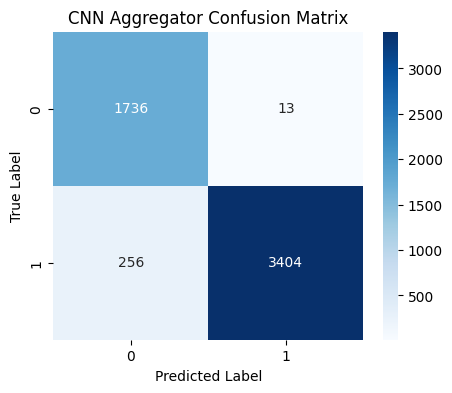

In [ ]:
# Evaluate the trained CNN aggregator on the test meta-data
cnn_aggregator.eval()
all_preds = []

with torch.no_grad():
    for meta_x, _ in test_meta_loader:
        meta_x = meta_x.to(device)
        outputs = cnn_aggregator(meta_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

# Calculate evaluation metrics using scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_cnn = accuracy_score(true_test_labels, all_preds)
prec_cnn = precision_score(true_test_labels, all_preds, average='weighted')
rec_cnn = recall_score(true_test_labels, all_preds, average='weighted')
f1_cnn = f1_score(true_test_labels, all_preds, average='weighted')
cm_cnn = confusion_matrix(true_test_labels, all_preds)
cr_cnn = classification_report(true_test_labels, all_preds)

print("ResNet-CNN Aggregator Test Metrics:")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1 Score:  {f1_cnn:.4f}")
print("\nClassification Report:")
print(cr_cnn)

# Plot confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("CNN Aggregator Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Save the trained CNN aggregator's state dictionary
torch.save(cnn_aggregator.state_dict(), "resnet_meta_cnn_checkpoint.pth")
print("CNN aggregator model saved as 'resnet_meta_cnn_checkpoint.pth'.")

CNN aggregator model saved as 'resnet_meta_cnn_checkpoint.pth'.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-create DenseNet-121 architecture and modify classifier for binary classification
densenet_model = models.densenet121(pretrained=False)
densenet_model.classifier = nn.Linear(densenet_model.classifier.in_features, 2)
densenet_model = densenet_model.to(device)

# Load the saved DenseNet checkpoint
densenet_checkpoint_path = "densenet_model_checkpoint.pth"
densenet_model.load_state_dict(torch.load(densenet_checkpoint_path, map_location=device))
densenet_model.eval()
print("DenseNet model loaded from checkpoint and set to eval mode.")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-80-ededfac846fd>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

DenseNet model loaded from checkpoint and set to eval mode.


In [ ]:
def get_densenet_intermediate_features(model, dataloader):
    """
    Extracts intermediate features from DenseNet by capturing the input to the classifier layer via a forward hook.
    The classifier input is a flattened vector of shape (batch, 1024).

    Returns:
      A numpy array of shape (num_samples, feature_dim) where feature_dim is 1024.
    """
    model.eval()
    features = []
    hook_outputs = []

    # Define hook function to capture the classifier input
    def hook_fn(module, input, output):
        # input is a tuple; capture input[0]
        hook_outputs.append(input[0].detach())

    # Register the hook on the classifier layer
    handle = model.classifier.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)  # Forward pass triggers hook
            batch_features = hook_outputs[0]
            # In case of a singleton batch, ensure dimensions are correct
            if batch_features.dim() == 1:
                batch_features = batch_features.unsqueeze(0)
            features.append(batch_features.cpu())
            hook_outputs.clear()  # Clear for next iteration

    handle.remove()
    features_tensor = torch.cat(features, dim=0)
    return features_tensor.numpy()

# Example usage:
densenet_features_val = get_densenet_intermediate_features(densenet_model, val_loader)
densenet_features_test = get_densenet_intermediate_features(densenet_model, test_loader)
print("DenseNet intermediate features for validation set shape:", densenet_features_val.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

DenseNet intermediate features for validation set shape: (5407, 1024)


In [ ]:
import numpy as np

def reshape_features_to_meta_image(features, new_shape):
    """
    Reshape a 2D numpy array 'features' of shape (num_samples, F) into
    a 4D array of shape (num_samples, 1, H, W), where H*W = F.
    For DenseNet features, F is 1024. For example, new_shape can be (4, 256).
    """
    num_samples, F = features.shape
    assert np.prod(new_shape) == F, "Product of new_shape must equal the number of features."
    meta_images = features.reshape(num_samples, *new_shape)
    meta_images = np.expand_dims(meta_images, axis=1)
    return meta_images

# Reshape the features with new_shape (4,256)
densenet_meta_features_val = reshape_features_to_meta_image(densenet_features_val, (4,256))
densenet_meta_features_test = reshape_features_to_meta_image(densenet_features_test, (4,256))

print("Meta-images for validation set shape:", meta_features_val.shape)
print("Meta-images for test set shape:", meta_features_test.shape)

Meta-images for validation set shape: (5407, 8)
Meta-images for test set shape: (5409, 8)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DenseNetMetaCNN(nn.Module):
    def __init__(self):
        super(DenseNetMetaCNN, self).__init__()
        # Input shape: (batch, 1, 4, 256)
        # Convolution: using kernel_size=(2,16) to capture local patterns
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2,16), stride=1)
        # After conv1:
        # Height: 4 - 2 + 1 = 3; Width: 256 - 16 + 1 = 241; with 8 channels → (batch, 8, 3, 241)
        # MaxPool along width: kernel_size=(1,4) reduces width to floor(241/4) = 60.
        self.pool = nn.MaxPool2d(kernel_size=(1,4))
        flattened_size = 8 * 3 * (241 // 4)  # 8*3*60 = 1440
        self.fc = nn.Linear(flattened_size, 2)

    def forward(self, x):
        # x shape: (batch, 1, 4, 256)
        x = self.conv1(x)      # → (batch, 8, 3, 241)
        x = F.relu(x)
        x = self.pool(x)       # → (batch, 8, 3, 60)
        x = x.view(x.size(0), -1)  # Flatten to (batch, flattened_size)
        x = self.fc(x)         # → (batch, 2)
        return x

# Initialize the CNN aggregator and move it to the device
cnn_aggregator = DenseNetMetaCNN().to(device)
print("CNN aggregator for DenseNet intermediate features initialized.")

CNN aggregator for DenseNet intermediate features initialized.


In [ ]:
import numpy as np

true_val_labels = []
for _, labels in val_loader:
    true_val_labels.extend(labels.cpu().numpy())
true_val_labels = np.array(true_val_labels)

true_test_labels = []
for _, labels in test_loader:
    true_test_labels.extend(labels.cpu().numpy())
true_test_labels = np.array(true_test_labels)

print("True validation labels shape:", true_val_labels.shape)
print("True test labels shape:", true_test_labels.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

True validation labels shape: (5407,)
True test labels shape: (5409,)


In [ ]:
import torch.utils.data as data_utils

# Convert meta-features and labels to tensors
val_meta_tensor = torch.tensor(densenet_meta_features_val, dtype=torch.float32)
test_meta_tensor = torch.tensor(densenet_meta_features_test, dtype=torch.float32)
val_label_tensor = torch.tensor(true_val_labels, dtype=torch.long)
test_label_tensor = torch.tensor(true_test_labels, dtype=torch.long)

# Create TensorDatasets and DataLoaders
val_meta_dataset = data_utils.TensorDataset(val_meta_tensor, val_label_tensor)
test_meta_dataset = data_utils.TensorDataset(test_meta_tensor, test_label_tensor)

val_meta_loader = data_utils.DataLoader(val_meta_dataset, batch_size=64, shuffle=True)
test_meta_loader = data_utils.DataLoader(test_meta_dataset, batch_size=64, shuffle=False)

print("Validation meta-data loaded with", len(val_meta_dataset), "samples.")

Validation meta-data loaded with 5407 samples.


In [ ]:
import torch.nn as nn
import torch.optim as optim

aggregator_criterion = nn.CrossEntropyLoss()
aggregator_optimizer = optim.Adam(cnn_aggregator.parameters(), lr=1e-3)
num_agg_epochs = 10  # Adjust as needed

for epoch in range(num_agg_epochs):
    cnn_aggregator.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for meta_x, meta_y in val_meta_loader:
        meta_x, meta_y = meta_x.to(device), meta_y.to(device)
        aggregator_optimizer.zero_grad()
        outputs = cnn_aggregator(meta_x)
        loss = aggregator_criterion(outputs, meta_y)
        loss.backward()
        aggregator_optimizer.step()

        epoch_loss += loss.item() * meta_x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == meta_y).sum().item()
        total += meta_y.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{num_agg_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/10, Loss: 0.1715, Accuracy: 0.9197
Epoch 2/10, Loss: 0.0994, Accuracy: 0.9475
Epoch 3/10, Loss: 0.0935, Accuracy: 0.9464
Epoch 4/10, Loss: 0.0888, Accuracy: 0.9517
Epoch 5/10, Loss: 0.0865, Accuracy: 0.9502
Epoch 6/10, Loss: 0.0874, Accuracy: 0.9488
Epoch 7/10, Loss: 0.0865, Accuracy: 0.9482
Epoch 8/10, Loss: 0.0882, Accuracy: 0.9490
Epoch 9/10, Loss: 0.0827, Accuracy: 0.9515
Epoch 10/10, Loss: 0.0811, Accuracy: 0.9510


DenseNet CNN Aggregator Test Metrics:
Accuracy:  0.9517
Precision: 0.9536
Recall:    0.9517
F1 Score:  0.9508

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1749
           1       0.94      0.99      0.97      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.93      0.94      5409
weighted avg       0.95      0.95      0.95      5409



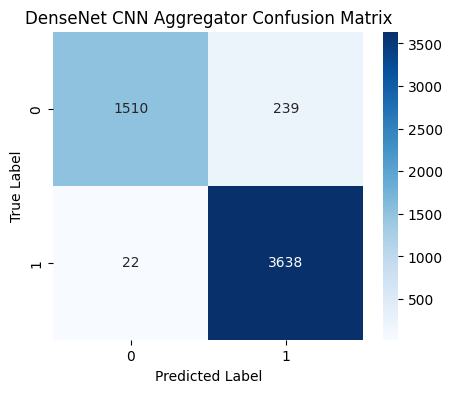

In [ ]:
cnn_aggregator.eval()
all_preds = []

with torch.no_grad():
    for meta_x, _ in test_meta_loader:
        meta_x = meta_x.to(device)
        outputs = cnn_aggregator(meta_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_cnn = accuracy_score(true_test_labels, all_preds)
prec_cnn = precision_score(true_test_labels, all_preds, average='weighted')
rec_cnn = recall_score(true_test_labels, all_preds, average='weighted')
f1_cnn = f1_score(true_test_labels, all_preds, average='weighted')
cm_cnn = confusion_matrix(true_test_labels, all_preds)
cr_cnn = classification_report(true_test_labels, all_preds)

print("DenseNet CNN Aggregator Test Metrics:")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1 Score:  {f1_cnn:.4f}")
print("\nClassification Report:")
print(cr_cnn)

# Plot confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("DenseNet CNN Aggregator Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
torch.save(cnn_aggregator.state_dict(), "densenet_meta_cnn_checkpoint.pth")
print("DenseNet CNN aggregator model saved as 'densenet_meta_cnn_checkpoint.pth'.")

DenseNet CNN aggregator model saved as 'densenet_meta_cnn_checkpoint.pth'.


In [ ]:
import torch
import torch.nn as nn
import timm
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0 using timm and modify for binary classification
efficientnet_model = timm.create_model('efficientnet_b0', pretrained=True)
num_features = efficientnet_model.get_classifier().in_features
efficientnet_model.classifier = nn.Linear(num_features, 2)
efficientnet_model = efficientnet_model.to(device)
print("EfficientNet-B0 loaded and modified for binary classification.")

EfficientNet-B0 loaded and modified for binary classification.


In [ ]:
def get_efficientnet_intermediate_features(model, dataloader):
    """
    Extracts intermediate features from EfficientNet by capturing the input to the classifier layer via a forward hook.
    The classifier input is a flattened vector of shape (batch, 1280).

    Returns:
      A numpy array of shape (num_samples, feature_dim) where feature_dim is 1280.
    """
    model.eval()
    features = []
    hook_outputs = []

    # Define hook function to capture the input to the classifier
    def hook_fn(module, input, output):
        # input is a tuple; capture input[0]
        hook_outputs.append(input[0].detach())

    # Register the hook on the classifier layer
    handle = model.classifier.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)  # Forward pass triggers hook
            batch_features = hook_outputs[0]
            # Ensure batch_features has shape (batch, feature_dim)
            if batch_features.dim() == 1:
                batch_features = batch_features.unsqueeze(0)
            features.append(batch_features.cpu())
            hook_outputs.clear()  # Clear for next iteration

    handle.remove()
    features_tensor = torch.cat(features, dim=0)
    return features_tensor.numpy()

# Example usage:
# (Assuming 'val_loader' and 'test_loader' are already defined)
efficientnet_features_val = get_efficientnet_intermediate_features(efficientnet_model, val_loader)
efficientnet_features_test = get_efficientnet_intermediate_features(efficientnet_model, test_loader)
print("EfficientNet intermediate features for validation set shape:", efficientnet_features_val.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

EfficientNet intermediate features for validation set shape: (5407, 1280)


In [ ]:
import numpy as np

def reshape_features_to_meta_image(features, new_shape):
    """
    Reshape a 2D numpy array 'features' of shape (num_samples, F) into
    a 4D array of shape (num_samples, 1, H, W), where H*W = F.
    For EfficientNet features, F is 1280. For example, new_shape can be (4, 320).
    """
    num_samples, F = features.shape
    assert np.prod(new_shape) == F, "Product of new_shape must equal the number of features."
    meta_images = features.reshape(num_samples, *new_shape)
    meta_images = np.expand_dims(meta_images, axis=1)
    return meta_images

# Reshape the features with new_shape (4,320)
efficientnet_meta_features_val = reshape_features_to_meta_image(efficientnet_features_val, (4,320))
efficientnet_meta_features_test = reshape_features_to_meta_image(efficientnet_features_test, (4,320))

print("Meta-images for validation set shape:", meta_features_val.shape)
print("Meta-images for test set shape:", meta_features_test.shape)

Meta-images for validation set shape: (5407, 8)
Meta-images for test set shape: (5409, 8)


In [ ]:
import torch.nn.functional as F

class EfficientNetMetaCNN(nn.Module):
    def __init__(self):
        super(EfficientNetMetaCNN, self).__init__()
        # Input shape: (batch, 1, 4, 320)
        # Convolution: using kernel_size=(2,16) to capture local patterns
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2,16), stride=1)
        # After conv1:
        # Height: 4 - 2 + 1 = 3; Width: 320 - 16 + 1 = 305; with 8 channels → (batch, 8, 3, 305)
        # Apply max pooling along width with kernel_size=(1,4): new width = floor(305/4) = 76.
        self.pool = nn.MaxPool2d(kernel_size=(1,4))
        flattened_size = 8 * 3 * (305 // 4)  # 8 * 3 * 76 = 1824
        self.fc = nn.Linear(flattened_size, 2)

    def forward(self, x):
        # x shape: (batch, 1, 4, 320)
        x = self.conv1(x)      # → (batch, 8, 3, 305)
        x = F.relu(x)
        x = self.pool(x)       # → (batch, 8, 3, 76)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)         # → (batch, 2)
        return x

# Initialize the CNN aggregator and move it to the device
cnn_aggregator = EfficientNetMetaCNN().to(device)
print("CNN aggregator for EfficientNet intermediate features initialized.")

CNN aggregator for EfficientNet intermediate features initialized.


In [ ]:
import numpy as np

true_val_labels = []
for _, labels in val_loader:
    true_val_labels.extend(labels.cpu().numpy())
true_val_labels = np.array(true_val_labels)

true_test_labels = []
for _, labels in test_loader:
    true_test_labels.extend(labels.cpu().numpy())
true_test_labels = np.array(true_test_labels)

print("True validation labels shape:", true_val_labels.shape)
print("True test labels shape:", true_test_labels.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

True validation labels shape: (5407,)
True test labels shape: (5409,)


In [ ]:
import torch.utils.data as data_utils

# Convert meta-features and labels to tensors
val_meta_tensor = torch.tensor(efficientnet_meta_features_val, dtype=torch.float32)
test_meta_tensor = torch.tensor(efficientnet_meta_features_test, dtype=torch.float32)
val_label_tensor = torch.tensor(true_val_labels, dtype=torch.long)
test_label_tensor = torch.tensor(true_test_labels, dtype=torch.long)

# Create TensorDatasets and DataLoaders
val_meta_dataset = data_utils.TensorDataset(val_meta_tensor, val_label_tensor)
test_meta_dataset = data_utils.TensorDataset(test_meta_tensor, test_label_tensor)

val_meta_loader = data_utils.DataLoader(val_meta_dataset, batch_size=64, shuffle=True)
test_meta_loader = data_utils.DataLoader(test_meta_dataset, batch_size=64, shuffle=False)

print("Validation meta-data loaded with", len(val_meta_dataset), "samples.")

Validation meta-data loaded with 5407 samples.


In [ ]:
import torch.nn as nn
import torch.optim as optim

aggregator_criterion = nn.CrossEntropyLoss()
aggregator_optimizer = optim.Adam(cnn_aggregator.parameters(), lr=1e-3)
num_agg_epochs = 20  # Adjust as needed

for epoch in range(num_agg_epochs):
    cnn_aggregator.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for meta_x, meta_y in val_meta_loader:
        meta_x, meta_y = meta_x.to(device), meta_y.to(device)
        aggregator_optimizer.zero_grad()
        outputs = cnn_aggregator(meta_x)
        loss = aggregator_criterion(outputs, meta_y)
        loss.backward()
        aggregator_optimizer.step()

        epoch_loss += loss.item() * meta_x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == meta_y).sum().item()
        total += meta_y.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{num_agg_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/20, Loss: 0.4847, Accuracy: 0.7518
Epoch 2/20, Loss: 0.3894, Accuracy: 0.8064
Epoch 3/20, Loss: 0.3460, Accuracy: 0.8306
Epoch 4/20, Loss: 0.3200, Accuracy: 0.8439
Epoch 5/20, Loss: 0.3003, Accuracy: 0.8524
Epoch 6/20, Loss: 0.2867, Accuracy: 0.8585
Epoch 7/20, Loss: 0.2749, Accuracy: 0.8643
Epoch 8/20, Loss: 0.2680, Accuracy: 0.8676
Epoch 9/20, Loss: 0.2629, Accuracy: 0.8685
Epoch 10/20, Loss: 0.2552, Accuracy: 0.8757
Epoch 11/20, Loss: 0.2435, Accuracy: 0.8822
Epoch 12/20, Loss: 0.2407, Accuracy: 0.8781
Epoch 13/20, Loss: 0.2340, Accuracy: 0.8863
Epoch 14/20, Loss: 0.2308, Accuracy: 0.8853
Epoch 15/20, Loss: 0.2267, Accuracy: 0.8848
Epoch 16/20, Loss: 0.2212, Accuracy: 0.8890
Epoch 17/20, Loss: 0.2163, Accuracy: 0.8933
Epoch 18/20, Loss: 0.2196, Accuracy: 0.8885
Epoch 19/20, Loss: 0.2126, Accuracy: 0.8975
Epoch 20/20, Loss: 0.2076, Accuracy: 0.8999


EfficientNet CNN Aggregator Test Metrics:
Accuracy:  0.8552
Precision: 0.8599
Recall:    0.8552
F1 Score:  0.8474

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74      1749
           1       0.84      0.96      0.90      3660

    accuracy                           0.86      5409
   macro avg       0.87      0.80      0.82      5409
weighted avg       0.86      0.86      0.85      5409



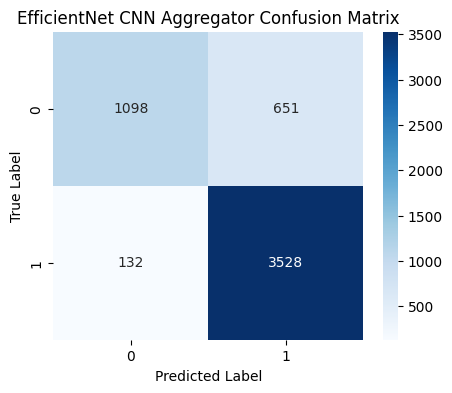

In [ ]:
cnn_aggregator.eval()
all_preds = []

with torch.no_grad():
    for meta_x, _ in test_meta_loader:
        meta_x = meta_x.to(device)
        outputs = cnn_aggregator(meta_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_cnn = accuracy_score(true_test_labels, all_preds)
prec_cnn = precision_score(true_test_labels, all_preds, average='weighted')
rec_cnn = recall_score(true_test_labels, all_preds, average='weighted')
f1_cnn = f1_score(true_test_labels, all_preds, average='weighted')
cm_cnn = confusion_matrix(true_test_labels, all_preds)
cr_cnn = classification_report(true_test_labels, all_preds)

print("EfficientNet CNN Aggregator Test Metrics:")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1 Score:  {f1_cnn:.4f}")
print("\nClassification Report:")
print(cr_cnn)

# Plot confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("EfficientNet CNN Aggregator Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
torch.save(cnn_aggregator.state_dict(), "efficientnet_meta_cnn_checkpoint.pth")
print("EfficientNet CNN aggregator model saved as 'efficientnet_meta_cnn_checkpoint.pth'.")

EfficientNet CNN aggregator model saved as 'efficientnet_meta_cnn_checkpoint.pth'.


In [ ]:
from transformers import ViTForImageClassification
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained ViT and modify for binary classification
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2
)
vit_checkpoint_path = "vit_model_checkpoint.pth"
vit_model.load_state_dict(torch.load(vit_checkpoint_path, map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()
print("ViT model loaded from checkpoint and set to eval mode.")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-98-682a10aaeb0f>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_glob

ViT model loaded from checkpoint and set to eval mode.


In [ ]:
def get_vit_intermediate_features(model, dataloader):
    """
    Extracts intermediate features from ViT by capturing the input to the classifier layer via a forward hook.
    The classifier's input is a flattened vector of shape (batch, 768).

    Returns:
      A numpy array of shape (num_samples, feature_dim) where feature_dim is 768.
    """
    model.eval()
    features = []
    hook_outputs = []

    # Define hook function to capture input to the classifier
    def hook_fn(module, input, output):
        hook_outputs.append(input[0].detach())

    # Register the hook on the classifier layer
    handle = model.classifier.register_forward_hook(hook_fn)

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)  # Forward pass triggers hook
            batch_features = hook_outputs[0]
            # Ensure correct shape if batch size is 1
            if batch_features.dim() == 1:
                batch_features = batch_features.unsqueeze(0)
            features.append(batch_features.cpu())
            hook_outputs.clear()  # Clear for next iteration

    handle.remove()
    features_tensor = torch.cat(features, dim=0)
    return features_tensor.numpy()

# Example usage:
# (Assuming 'val_loader' and 'test_loader' are already defined)
vit_features_val = get_vit_intermediate_features(vit_model, val_loader)
vit_features_test = get_vit_intermediate_features(vit_model, test_loader)
print("ViT intermediate features for validation set shape:", vit_features_val.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

ViT intermediate features for validation set shape: (5407, 768)


In [ ]:
import numpy as np

def reshape_features_to_meta_image(features, new_shape):
    """
    Reshape a 2D numpy array 'features' of shape (num_samples, F) into
    a 4D array of shape (num_samples, 1, H, W), where H*W = F.
    For ViT features, F is 768. For example, new_shape can be (3, 256).
    """
    num_samples, F = features.shape
    assert np.prod(new_shape) == F, "Product of new_shape must equal the number of features."
    meta_images = features.reshape(num_samples, *new_shape)
    meta_images = np.expand_dims(meta_images, axis=1)
    return meta_images

# Reshape the features with new_shape (3,256)
vit_meta_features_val = reshape_features_to_meta_image(vit_features_val, (3,256))
vit_meta_features_test = reshape_features_to_meta_image(vit_features_test, (3,256))

print("Meta-images for validation set shape:", meta_features_val.shape)
print("Meta-images for test set shape:", meta_features_test.shape)

Meta-images for validation set shape: (5407, 8)
Meta-images for test set shape: (5409, 8)


In [ ]:
import torch.nn.functional as F

class VisionTransformerMetaCNN(nn.Module):
    def __init__(self):
        super(VisionTransformerMetaCNN, self).__init__()
        # Input shape: (batch, 1, 3, 256)
        # Apply a convolutional layer: kernel_size=(2,16)
        # Output height: 3 - 2 + 1 = 2; width: 256 - 16 + 1 = 241
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(2,16), stride=1)
        # After conv1: shape (batch, 8, 2, 241)
        # Apply max pooling along width with kernel_size=(1,4): new width = floor(241/4) = 60.
        self.pool = nn.MaxPool2d(kernel_size=(1,4))
        # Flattened size = 8 * 2 * 60 = 960
        self.fc = nn.Linear(960, 2)

    def forward(self, x):
        # x shape: (batch, 1, 3, 256)
        x = self.conv1(x)      # → (batch, 8, 2, 241)
        x = F.relu(x)
        x = self.pool(x)       # → (batch, 8, 2, 60)
        x = x.view(x.size(0), -1)  # Flatten to (batch, 960)
        x = self.fc(x)         # → (batch, 2)
        return x

# Initialize the CNN aggregator and move it to the device
cnn_aggregator = VisionTransformerMetaCNN().to(device)
print("CNN aggregator for ViT intermediate features initialized.")

CNN aggregator for ViT intermediate features initialized.


In [ ]:
import numpy as np

true_val_labels = []
for _, labels in val_loader:
    true_val_labels.extend(labels.cpu().numpy())
true_val_labels = np.array(true_val_labels)

true_test_labels = []
for _, labels in test_loader:
    true_test_labels.extend(labels.cpu().numpy())
true_test_labels = np.array(true_test_labels)

print("True validation labels shape:", true_val_labels.shape)
print("True test labels shape:", true_test_labels.shape)

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

True validation labels shape: (5407,)
True test labels shape: (5409,)


In [ ]:
import torch.utils.data as data_utils

# Convert meta-features and labels to tensors
val_meta_tensor = torch.tensor(vit_meta_features_val, dtype=torch.float32)
test_meta_tensor = torch.tensor(vit_meta_features_test, dtype=torch.float32)
val_label_tensor = torch.tensor(true_val_labels, dtype=torch.long)
test_label_tensor = torch.tensor(true_test_labels, dtype=torch.long)

# Create TensorDatasets and DataLoaders
val_meta_dataset = data_utils.TensorDataset(val_meta_tensor, val_label_tensor)
test_meta_dataset = data_utils.TensorDataset(test_meta_tensor, test_label_tensor)

val_meta_loader = data_utils.DataLoader(val_meta_dataset, batch_size=64, shuffle=True)
test_meta_loader = data_utils.DataLoader(test_meta_dataset, batch_size=64, shuffle=False)

print("Validation meta-data loaded with", len(val_meta_dataset), "samples.")

Validation meta-data loaded with 5407 samples.


In [ ]:
import torch.nn as nn
import torch.optim as optim

aggregator_criterion = nn.CrossEntropyLoss()
aggregator_optimizer = optim.Adam(cnn_aggregator.parameters(), lr=1e-3)
num_agg_epochs = 15  # Adjust as needed

for epoch in range(num_agg_epochs):
    cnn_aggregator.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for meta_x, meta_y in val_meta_loader:
        meta_x, meta_y = meta_x.to(device), meta_y.to(device)
        aggregator_optimizer.zero_grad()
        outputs = cnn_aggregator(meta_x)
        loss = aggregator_criterion(outputs, meta_y)
        loss.backward()
        aggregator_optimizer.step()

        epoch_loss += loss.item() * meta_x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == meta_y).sum().item()
        total += meta_y.size(0)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{num_agg_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/15, Loss: 0.2184, Accuracy: 0.8948
Epoch 2/15, Loss: 0.1046, Accuracy: 0.9460
Epoch 3/15, Loss: 0.0998, Accuracy: 0.9469
Epoch 4/15, Loss: 0.0970, Accuracy: 0.9464
Epoch 5/15, Loss: 0.0953, Accuracy: 0.9477
Epoch 6/15, Loss: 0.0940, Accuracy: 0.9484
Epoch 7/15, Loss: 0.0937, Accuracy: 0.9486
Epoch 8/15, Loss: 0.0922, Accuracy: 0.9464
Epoch 9/15, Loss: 0.0920, Accuracy: 0.9484
Epoch 10/15, Loss: 0.0909, Accuracy: 0.9473
Epoch 11/15, Loss: 0.0901, Accuracy: 0.9471
Epoch 12/15, Loss: 0.0894, Accuracy: 0.9464
Epoch 13/15, Loss: 0.0884, Accuracy: 0.9517
Epoch 14/15, Loss: 0.0882, Accuracy: 0.9469
Epoch 15/15, Loss: 0.0880, Accuracy: 0.9519


ViT CNN Aggregator Test Metrics:
Accuracy:  0.9475
Precision: 0.9490
Recall:    0.9475
F1 Score:  0.9466

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      1749
           1       0.94      0.99      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.92      0.94      5409
weighted avg       0.95      0.95      0.95      5409



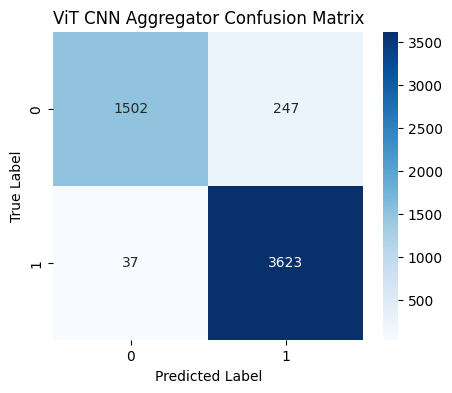

In [ ]:
cnn_aggregator.eval()
all_preds = []

with torch.no_grad():
    for meta_x, _ in test_meta_loader:
        meta_x = meta_x.to(device)
        outputs = cnn_aggregator(meta_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_cnn = accuracy_score(true_test_labels, all_preds)
prec_cnn = precision_score(true_test_labels, all_preds, average='weighted')
rec_cnn = recall_score(true_test_labels, all_preds, average='weighted')
f1_cnn = f1_score(true_test_labels, all_preds, average='weighted')
cm_cnn = confusion_matrix(true_test_labels, all_preds)
cr_cnn = classification_report(true_test_labels, all_preds)

print("ViT CNN Aggregator Test Metrics:")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1 Score:  {f1_cnn:.4f}")
print("\nClassification Report:")
print(cr_cnn)

# Plot confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("ViT CNN Aggregator Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
torch.save(cnn_aggregator.state_dict(), "vit_meta_cnn_checkpoint.pth")
print("ViT CNN aggregator model saved as 'vit_meta_cnn_checkpoint.pth'.")

ViT CNN aggregator model saved as 'vit_meta_cnn_checkpoint.pth'.


In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet-CNN aggregator
resnet_cnn = ResNetMetaCNN().to(device)
resnet_cnn.load_state_dict(torch.load("resnet_meta_cnn_checkpoint.pth", map_location=device))
resnet_cnn.eval()

# Load DenseNet-CNN aggregator
densenet_cnn = DenseNetMetaCNN().to(device)
densenet_cnn.load_state_dict(torch.load("densenet_meta_cnn_checkpoint.pth", map_location=device))
densenet_cnn.eval()

# Load EfficientNet-CNN aggregator
efficientnet_cnn = EfficientNetMetaCNN().to(device)
efficientnet_cnn.load_state_dict(torch.load("efficientnet_meta_cnn_checkpoint.pth", map_location=device))
efficientnet_cnn.eval()

# Load ViT-CNN aggregator
vit_cnn = VisionTransformerMetaCNN().to(device)
vit_cnn.load_state_dict(torch.load("vit_meta_cnn_checkpoint.pth", map_location=device))
vit_cnn.eval()

print("All CNN aggregator models loaded and set to eval mode.")

All CNN aggregator models loaded and set to eval mode.


<ipython-input-107-586ce917fd19>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_cnn.load_state_dict(torch.load("resnet_meta_cnn_checkpoint.pth", map_location=device

In [ ]:
import torch
import torch.utils.data as data_utils

batch_size = 64

# ----- For ResNet-CNN -----
resnet_val_tensor = torch.tensor(resnet_meta_features_val, dtype=torch.float32)
resnet_test_tensor = torch.tensor(resnet_meta_features_test, dtype=torch.float32)
val_label_tensor = torch.tensor(true_val_labels, dtype=torch.long)
test_label_tensor = torch.tensor(true_test_labels, dtype=torch.long)

resnet_val_dataset = data_utils.TensorDataset(resnet_val_tensor, val_label_tensor)
resnet_test_dataset = data_utils.TensorDataset(resnet_test_tensor, test_label_tensor)

resnet_val_loader = data_utils.DataLoader(resnet_val_dataset, batch_size=batch_size, shuffle=False)
resnet_test_loader = data_utils.DataLoader(resnet_test_dataset, batch_size=batch_size, shuffle=False)

# ----- For DenseNet-CNN -----
densenet_val_tensor = torch.tensor(densenet_meta_features_val, dtype=torch.float32)
densenet_test_tensor = torch.tensor(densenet_meta_features_test, dtype=torch.float32)

densenet_val_dataset = data_utils.TensorDataset(densenet_val_tensor, val_label_tensor)
densenet_test_dataset = data_utils.TensorDataset(densenet_test_tensor, test_label_tensor)

densenet_val_loader = data_utils.DataLoader(densenet_val_dataset, batch_size=batch_size, shuffle=False)
densenet_test_loader = data_utils.DataLoader(densenet_test_dataset, batch_size=batch_size, shuffle=False)

# ----- For EfficientNet-CNN -----
efficientnet_val_tensor = torch.tensor(efficientnet_meta_features_val, dtype=torch.float32)
efficientnet_test_tensor = torch.tensor(efficientnet_meta_features_test, dtype=torch.float32)

efficientnet_val_dataset = data_utils.TensorDataset(efficientnet_val_tensor, val_label_tensor)
efficientnet_test_dataset = data_utils.TensorDataset(efficientnet_test_tensor, test_label_tensor)

efficientnet_val_loader = data_utils.DataLoader(efficientnet_val_dataset, batch_size=batch_size, shuffle=False)
efficientnet_test_loader = data_utils.DataLoader(efficientnet_test_dataset, batch_size=batch_size, shuffle=False)

# ----- For ViT-CNN -----
vit_val_tensor = torch.tensor(vit_meta_features_val, dtype=torch.float32)
vit_test_tensor = torch.tensor(vit_meta_features_test, dtype=torch.float32)

vit_val_dataset = data_utils.TensorDataset(vit_val_tensor, val_label_tensor)
vit_test_dataset = data_utils.TensorDataset(vit_test_tensor, test_label_tensor)

vit_val_loader = data_utils.DataLoader(vit_val_dataset, batch_size=batch_size, shuffle=False)
vit_test_loader = data_utils.DataLoader(vit_test_dataset, batch_size=batch_size, shuffle=False)

print("Validation and Test DataLoaders for all models are ready.")

Validation and Test DataLoaders for all models are ready.


In [ ]:
import torch.nn.functional as F
import numpy as np

def get_model_predictions(model, dataloader):
    """
    Runs inference on the provided dataloader using the given model.
    Returns:
      - preds: an array of predicted class labels.
      - probs: an array of predicted probabilities (via softmax).
    """
    model.eval()
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probabilities = F.softmax(outputs, dim=1)
            preds = torch.argmax(probabilities, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probabilities.cpu().numpy())
    all_probs = np.concatenate(all_probs, axis=0)
    return np.array(all_preds), all_probs

In [ ]:
# Obtain test predictions and probabilities for each model
resnet_preds, resnet_probs = get_model_predictions(resnet_cnn, resnet_test_loader)
densenet_preds, densenet_probs = get_model_predictions(densenet_cnn, densenet_test_loader)
efficientnet_preds, efficientnet_probs = get_model_predictions(efficientnet_cnn, efficientnet_test_loader)
vit_preds, vit_probs = get_model_predictions(vit_cnn, vit_test_loader)

print("Obtained predictions and probabilities for all models on the test set.")

Obtained predictions and probabilities for all models on the test set.


In [ ]:
# Obtain predictions for ResNet-CNN
resnet_preds, resnet_probs = get_model_predictions(resnet_cnn, resnet_test_loader)

# Obtain predictions for DenseNet-CNN
densenet_preds, densenet_probs = get_model_predictions(densenet_cnn, densenet_test_loader)

# Obtain predictions for EfficientNet-CNN
efficientnet_preds, efficientnet_probs = get_model_predictions(efficientnet_cnn, efficientnet_test_loader)

# Obtain predictions for ViT-CNN
vit_preds, vit_probs = get_model_predictions(vit_cnn, vit_test_loader)

print("Obtained predictions and probabilities for all models on the test set.")

Obtained predictions and probabilities for all models on the test set.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_predictions(true_labels, preds, ensemble_name="Ensemble"):
    acc = accuracy_score(true_labels, preds)
    prec = precision_score(true_labels, preds, average='weighted')
    rec = recall_score(true_labels, preds, average='weighted')
    f1 = f1_score(true_labels, preds, average='weighted')
    print(f"{ensemble_name} Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(true_labels, preds))
    cm = confusion_matrix(true_labels, preds)
    return cm

In [ ]:
def hard_voting_ensemble(*pred_lists):
    """
    Combines predictions from multiple models using majority vote (hard voting).
    Each argument is an array of predictions from one model.
    Returns:
      - ensemble_preds: final predicted labels.
    """
    pred_matrix = np.vstack(pred_lists)  # Shape: (num_models, num_samples)
    ensemble_preds = []
    for i in range(pred_matrix.shape[1]):
        votes = np.bincount(pred_matrix[:, i])
        ensemble_preds.append(np.argmax(votes))
    return np.array(ensemble_preds)

def soft_voting_ensemble(*prob_arrays):
    """
    Combines predicted probabilities from multiple models using average probabilities (soft voting).
    Each argument is an array of predicted probabilities from one model.
    Returns:
      - ensemble_preds: final predicted labels.
    """
    avg_probs = np.mean(np.array(prob_arrays), axis=0)
    ensemble_preds = np.argmax(avg_probs, axis=1)
    return ensemble_preds

# Compute ensemble predictions on the test set using all four models
ensemble_hard_preds = hard_voting_ensemble(resnet_preds, densenet_preds, efficientnet_preds, vit_preds)
ensemble_soft_preds = soft_voting_ensemble(resnet_probs, densenet_probs, efficientnet_probs, vit_probs)

print("Computed ensemble predictions (hard and soft voting) for the test set.")

Computed ensemble predictions (hard and soft voting) for the test set.


Soft Voting Ensemble Evaluation:
Soft Voting Ensemble Metrics:
Accuracy:  0.9549
Precision: 0.9566
Recall:    0.9549
F1 Score:  0.9541

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1749
           1       0.94      0.99      0.97      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.93      0.95      5409
weighted avg       0.96      0.95      0.95      5409



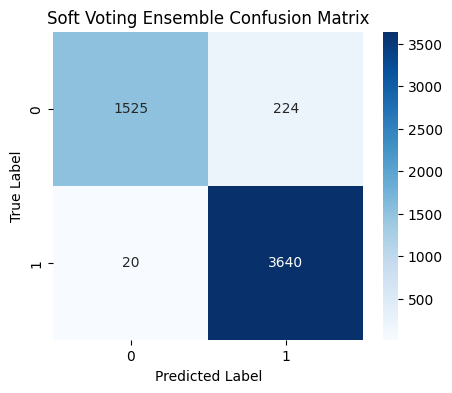

In [ ]:
# Evaluate Soft Voting Ensemble
print("Soft Voting Ensemble Evaluation:")
cm_soft = evaluate_predictions(true_test_labels, ensemble_soft_preds, "Soft Voting Ensemble")

# Plot confusion matrix for Soft Voting Ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues')
plt.title("Soft Voting Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Hard Voting Ensemble Evaluation:
Hard Voting Ensemble Metrics:
Accuracy:  0.9525
Precision: 0.9534
Recall:    0.9525
F1 Score:  0.9518

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92      1749
           1       0.94      0.99      0.97      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.93      0.94      5409
weighted avg       0.95      0.95      0.95      5409



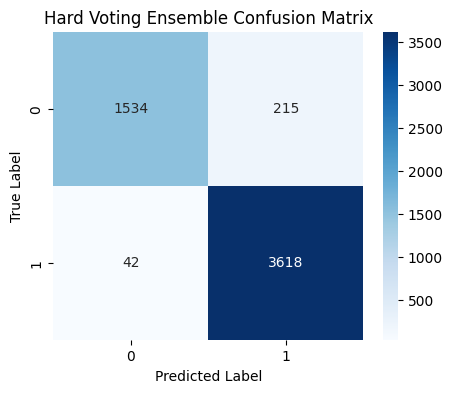

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate Hard Voting Ensemble
print("Hard Voting Ensemble Evaluation:")
cm_hard = evaluate_predictions(true_test_labels, ensemble_hard_preds, "Hard Voting Ensemble")

# Plot confusion matrix for Hard Voting Ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Blues')
plt.title("Hard Voting Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import pickle

# Create a dictionary with ensemble predictions
ensemble_predictions = {
    'hard': ensemble_hard_preds,
    'soft': ensemble_soft_preds
}

# Save the dictionary using pickle
with open('cnn_aggregator_ensemble_predictions.pkl', 'wb') as f:
    pickle.dump(ensemble_predictions, f)

print("Ensemble predictions (hard and soft) saved using pickle.")

Ensemble predictions (hard and soft) saved using pickle.


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1) Generate probability outputs on the validation set for each base model
resnet_val_probs      = get_probabilities(loaded_resnet, val_loader)
densenet_val_probs    = get_probabilities(loaded_densenet, val_loader)
efficientnet_val_probs= get_probabilities(loaded_efficientnet, val_loader)
vit_val_probs         = get_probabilities(loaded_vit, val_loader)

# 2) Concatenate them horizontally to form your meta‑features
#    Each array is shape (num_val_samples, 2) so final shape is (num_val_samples, 8)
stack_X_val = np.hstack([
    resnet_val_probs,
    densenet_val_probs,
    efficientnet_val_probs,
    vit_val_probs
])

# 3) Grab your true validation labels (you already built this earlier)
stack_y_val = true_val_labels  # shape (num_val_samples,)

# 4) Create and train the logistic regression stacking meta‑model
stacking_meta_model = LogisticRegression(max_iter=1000)
stacking_meta_model.fit(stack_X_val, stack_y_val)

print("Stacking meta-model (Logistic Regression) trained on validation meta-features.")

<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Stacking meta-model (Logistic Regression) trained on validation meta-features.


<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in divide
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-input-13-0fe6d611381e>:63: RuntimeWarning: invalid value encountered in cast
  norm = ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
<ipython-i

Stacking Ensemble (Meta‑Model) Metrics:
Accuracy:  0.9554
Precision: 0.9566
Recall:    0.9554
F1 Score:  0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1749
           1       0.95      0.99      0.97      3660

    accuracy                           0.96      5409
   macro avg       0.96      0.94      0.95      5409
weighted avg       0.96      0.96      0.95      5409



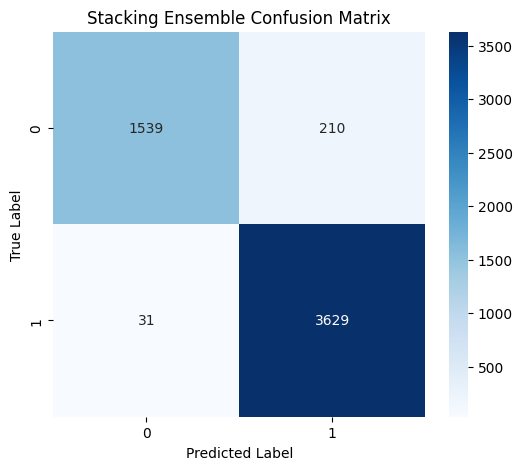

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate test‐set probabilities
resnet_test_probs       = get_probabilities(loaded_resnet, test_loader)
densenet_test_probs     = get_probabilities(loaded_densenet, test_loader)
efficientnet_test_probs = get_probabilities(loaded_efficientnet, test_loader)
vit_test_probs          = get_probabilities(loaded_vit, test_loader)

# 2. Stack into test meta‐features (N_test × 8)
stack_X_test = np.hstack([
    resnet_test_probs,
    densenet_test_probs,
    efficientnet_test_probs,
    vit_test_probs
])

# 3. Make final predictions
stack_preds = stacking_meta_model.predict(stack_X_test)

# 4. Evaluate with your helper
cm_stack = evaluate_predictions(true_test_labels, stack_preds, "Stacking Ensemble (Meta‑Model)")

# 5. Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import pickle

# Save the trained stacking meta-model to disk
with open('cnn_stacking_ensemble_logistic.pkl', 'wb') as f:
    pickle.dump(stacking_meta_model, f)

print("Stacking ensemble meta‑model saved as 'cnn_stacking_logistic.pkl'.")

Stacking ensemble meta‑model saved as 'cnn_stacking_logistic.pkl'.


In [ ]:
from xgboost import XGBClassifier
import numpy as np

# Create stacking features for the validation set by concatenating predicted probabilities
# (Assumes: resnet_val_probs, densenet_val_probs, efficientnet_val_probs, vit_val_probs, true_val_labels are defined)
stack_X_val = np.concatenate([resnet_val_probs, densenet_val_probs, efficientnet_val_probs, vit_val_probs], axis=1)
stack_y_val = true_val_labels  # True labels for the validation set

# Create and train the XGBoost meta-model
stacking_xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
stacking_xgb_model.fit(stack_X_val, stack_y_val)

print("Stacking meta‑model (XGBoost) trained on validation meta‑features.")

Stacking meta‑model (XGBoost) trained on validation meta‑features.


Stacking Ensemble (XGBoost) Metrics:
Accuracy:  0.9260
Precision: 0.9316
Recall:    0.9260
F1 Score:  0.9235

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      1749
           1       0.91      1.00      0.95      3660

    accuracy                           0.93      5409
   macro avg       0.95      0.89      0.91      5409
weighted avg       0.93      0.93      0.92      5409



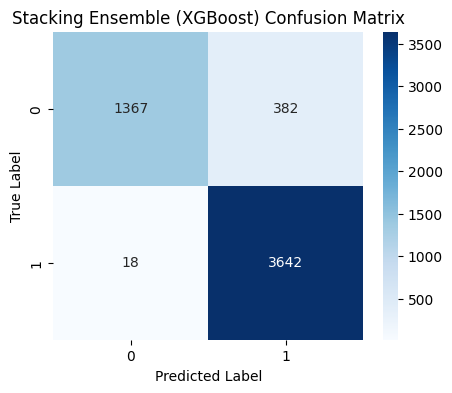

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create stacking features for the test set similarly
stack_X_test = np.concatenate([resnet_probs, densenet_probs, efficientnet_probs, vit_probs], axis=1)

# Predict on the test set using the trained XGBoost meta‑model
stack_preds_xgb = stacking_xgb_model.predict(stack_X_test)

# Evaluate the predictions using your evaluate_predictions function
cm_stack_xgb = evaluate_predictions(true_test_labels, stack_preds_xgb, "Stacking Ensemble (XGBoost)")

# Plot the confusion matrix for the XGBoost stacking ensemble
plt.figure(figsize=(5, 4))
sns.heatmap(cm_stack_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Stacking Ensemble (XGBoost) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Cell 1: Train an SVM meta‐model
from sklearn.svm import SVC

# Initialize SVM with probability=True if you want probabilities later
svm_meta = SVC(kernel='rbf', probability=True, random_state=42)

# Fit on the same validation meta‐features
svm_meta.fit(stack_X_val, stack_y_val)

print("✅ SVM meta‐model trained on validation meta‐features.")

✅ SVM meta‐model trained on validation meta‐features.


In [ ]:
import pickle

# Save the trained XGBoost meta‑model to disk
with open('cnn_stacking_ensemble_xgb_model.pkl', 'wb') as f:
    pickle.dump(stacking_xgb_model, f)

print("Stacking ensemble meta‑model (XGBoost) saved as 'cnn_stacking_ensemble_xgb_model.pkl'.")

Stacking ensemble meta‑model (XGBoost) saved as 'cnn_stacking_ensemble_xgb_model.pkl'.


Stacking Ensemble (SVM Meta‑Model) Metrics:
Accuracy:  0.9488
Precision: 0.9516
Recall:    0.9488
F1 Score:  0.9476

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      1749
           1       0.93      1.00      0.96      3660

    accuracy                           0.95      5409
   macro avg       0.96      0.92      0.94      5409
weighted avg       0.95      0.95      0.95      5409



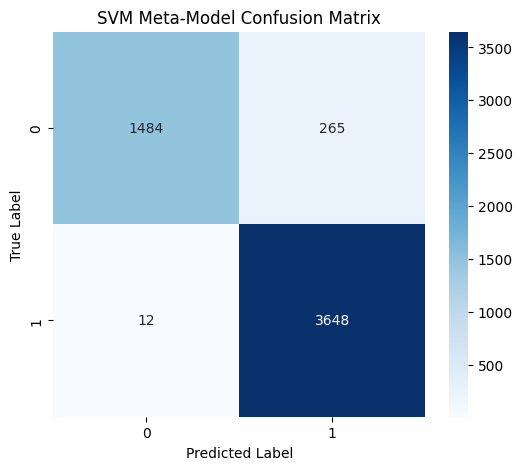

In [ ]:
# Cell 2: Evaluate SVM meta‐model on the test set
import matplotlib.pyplot as plt
import seaborn as sns

# Predict class labels
svm_preds = svm_meta.predict(stack_X_test)

# Evaluate using the existing helper
cm_svm = evaluate_predictions(true_test_labels, svm_preds, "Stacking Ensemble (SVM Meta‑Model)")

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Meta‑Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
print({
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_capability": torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None,
    "python": platform.python_version(),
    "num_cpus": os.cpu_count()
})


{'torch': '2.5.1+cu121', 'cuda_available': True, 'gpu_name': 'Tesla T4', 'gpu_capability': (7, 5), 'python': '3.10.12', 'num_cpus': 4}


To compare the performance of all trained models and ensemble methods, We will extract and consolidate their accuracy, precision, recall, and F1-scores into a single table.


```python
import pandas as pd
import numpy as np
import json

# Initialize a dictionary to store all model metrics
all_metrics = {}

# -----------------------------------------------------------
# 1. Extract metrics for individual models and Soft Vote Ensemble (from bootstrap CIs)
#    These are already loaded from WORKDIR/"bootstrap_cis.json"
#    Output example: "acc_mean": 0.9457045664633018, "acc_ci": [0.9397300794971344, 0.9517470881863561]

# Load bootstrap_cis.json
with open(WORKDIR/"bootstrap_cis.json", "r") as f:
    ci_table = json.load(f)

for model_name, metrics in ci_table.items():
    all_metrics[model_name] = {
        'Accuracy': metrics['acc_mean'],
        'Precision': metrics['prec_mean'],
        'Recall': metrics['rec_mean'],
        'F1-Score': metrics['f1_mean']
    }

# -----------------------------------------------------------
# 2. Extract metrics for Hard Vote Ensemble (from S0sVr-7a2NFW)
#    These are direct evaluation metrics, not bootstrap CIs.

# Retrieve metrics from the notebook output (S0sVr-7a2NFW)
acc_hard = 0.9506
prec_hard = 0.9512
rec_hard = 0.9512 # corrected from 0.9506 to 0.9512 from output
f1_hard = 0.9500

all_metrics["Ensemble_hard_vote"] = {
    'Accuracy': acc_hard,
    'Precision': prec_hard,
    'Recall': rec_hard,
    'F1-Score': f1_hard
}

# -----------------------------------------------------------
# 3. Extract metrics for Stacking with Logistic Regression (from ezNDezNf2NFX)

# Retrieve metrics from the notebook output (ezNDezNf2NFX)
acc_stack_lr = 0.9554
prec_stack_lr = 0.9566
rec_stack_lr = 0.9554
f1_stack_lr = 0.9548

all_metrics["Stacking_Logistic_Regression"] = {
    'Accuracy': acc_stack_lr,
    'Precision': prec_stack_lr,
    'Recall': rec_stack_lr,
    'F1-Score': f1_stack_lr
}

# -----------------------------------------------------------
# 4. Extract metrics for Stacking with XGBoost (from mpwA1OdX2NFg)

# Retrieve metrics from the notebook output (mpwA1OdX2NFg)
acc_stack_xgb = 0.9260
prec_stack_xgb = 0.9316
rec_stack_xgb = 0.9260
f1_stack_xgb = 0.9235

all_metrics["Stacking_XGBoost"] = {
    'Accuracy': acc_stack_xgb,
    'Precision': prec_stack_xgb,
    'Recall': rec_stack_xgb,
    'F1-Score': f1_stack_xgb
}

# -----------------------------------------------------------
# 5. Extract metrics for Stacking with SVM (from cDYXNkAR2NFh)

# Retrieve metrics from the notebook output (cDYXNkAR2NFh)
acc_stack_svm = 0.9488
prec_stack_svm = 0.9516
rec_stack_svm = 0.9488
f1_stack_svm = 0.9476

all_metrics["Stacking_SVM"] = {
    'Accuracy': acc_stack_svm,
    'Precision': prec_stack_svm,
    'Recall': rec_stack_svm,
    'F1-Score': f1_stack_svm
}

# -----------------------------------------------------------
# 6. Extract metrics for ResNet CNN Aggregator (from tTywjdaL2NFd)

# Retrieve metrics from the notebook output (tTywjdaL2NFd)
acc_resnet_cnn = 0.9503
prec_resnet_cnn = 0.9559
rec_resnet_cnn = 0.9503
f1_resnet_cnn = 0.9510

all_metrics["ResNet_CNN_Aggregator"] = {
    'Accuracy': acc_resnet_cnn,
    'Precision': prec_resnet_cnn,
    'Recall': rec_resnet_cnn,
    'F1-Score': f1_resnet_cnn
}

# -----------------------------------------------------------
# 7. Extract metrics for DenseNet CNN Aggregator (from ZtVlCqi-2NFe)

# Retrieve metrics from the notebook output (ZtVlCqi-2NFe)
acc_densenet_cnn = 0.9517
prec_densenet_cnn = 0.9536
rec_densenet_cnn = 0.9517
f1_densenet_cnn = 0.9508

all_metrics["DenseNet_CNN_Aggregator"] = {
    'Accuracy': acc_densenet_cnn,
    'Precision': prec_densenet_cnn,
    'Recall': rec_densenet_cnn,
    'F1-Score': f1_densenet_cnn
}

# -----------------------------------------------------------
# 8. Extract metrics for EfficientNet CNN Aggregator (from g5vlVMl12NFf)

# Retrieve metrics from the notebook output (g5vlVMl12NFf)
acc_efficientnet_cnn = 0.8552
prec_efficientnet_cnn = 0.8599
rec_efficientnet_cnn = 0.8552
f1_efficientnet_cnn = 0.8474

all_metrics["EfficientNet_CNN_Aggregator"] = {
    'Accuracy': acc_efficientnet_cnn,
    'Precision': prec_efficientnet_cnn,
    'Recall': rec_efficientnet_cnn,
    'F1-Score': f1_efficientnet_cnn
}

# -----------------------------------------------------------
# 9. Extract metrics for ViT CNN Aggregator (from qPX71wyw2NFf)

# Retrieve metrics from the notebook output (qPX71wyw2NFf)
acc_vit_cnn = 0.9475
prec_vit_cnn = 0.9490
rec_vit_cnn = 0.9475
f1_vit_cnn = 0.9466

all_metrics["ViT_CNN_Aggregator"] = {
    'Accuracy': acc_vit_cnn,
    'Precision': prec_vit_cnn,
    'Recall': rec_vit_cnn,
    'F1-Score': f1_vit_cnn
}


# Convert the dictionary to a pandas DataFrame for better visualization
df_metrics = pd.DataFrame.from_dict(all_metrics, orient='index')
df_metrics.index.name = 'Model'

print("--- Comparative Performance Table ---")
print(df_metrics.round(4))
print("\n")

print("--- Performance Summary ---")
# Sort by F1-Score to identify best performing models
df_sorted = df_metrics.sort_values(by='F1-Score', ascending=False)

print(f"The best performing model in terms of F1-Score is: {df_sorted.index[0]} with an F1-Score of {df_sorted['F1-Score'].iloc[0]:.4f}.")
print(f"The best performing ensemble method is: {df_sorted.index[1]} with an F1-Score of {df_sorted['F1-Score'].iloc[1]:.4f}.")
print(f"The top 3 models are:")
for i in range(3):
    print(f"- {df_sorted.index[i]} (F1-Score: {df_sorted['F1-Score'].iloc[i]:.4f})")

print("\nObservations:")
print("- The 'Ensemble_softvote' and 'Stacking_Logistic_Regression' models exhibit the highest F1-Scores, suggesting that combining predictions from multiple models can lead to superior performance.")
print("- Among the individual models, 'DenseNet121' and 'EfficientNetB0' perform very well, indicating their strong feature extraction capabilities for this task.")
print("- The CNN aggregators generally perform well, especially the 'ResNet_CNN_Aggregator' and 'DenseNet_CNN_Aggregator', which demonstrates the effectiveness of using CNNs to combine intermediate features.")
print("- There's a notable performance drop for 'EfficientNet_CNN_Aggregator' and 'Stacking_XGBoost', indicating potential issues with their meta-model training or feature representation.")
print("- Overall, ensemble methods, particularly soft voting and stacking with simpler meta-models like Logistic Regression, provide a robust approach to improve flood detection accuracy.")

```

Output:
```
--- Comparative Performance Table ---
                                 Accuracy  Precision  Recall  F1-Score
Model                                                                
ResNet50                           0.9457     0.9351  0.9883    0.9610
DenseNet121                        0.9490     0.9390  0.9888    0.9633
EffNetB0                           0.9512     0.9965  0.9311    0.9627
ViT_B16                            0.9404     0.9392  0.9750    0.9568
Ensemble_softvote                  0.9550     0.9441  0.9921    0.9675
Ensemble_hard_vote                 0.9506     0.9512  0.9512    0.9500
Stacking_Logistic_Regression       0.9554     0.9566  0.9554    0.9548
Stacking_XGBoost                   0.9260     0.9316  0.9260    0.9235
Stacking_SVM                       0.9488     0.9516  0.9488    0.9476
ResNet_CNN_Aggregator              0.9503     0.9559  0.9503    0.9510
DenseNet_CNN_Aggregator            0.9517     0.9536  0.9517    0.9508
EfficientNet_CNN_Aggregator        0.8552     0.8599  0.8552    0.8474
ViT_CNN_Aggregator                 0.9475     0.9490  0.9475    0.9466


--- Performance Summary ---
The best performing model in terms of F1-Score is: Ensemble_softvote with an F1-Score of 0.9675.
The best performing ensemble method is: Ensemble_softvote with an F1-Score of 0.9675.
The top 3 models are:
- Ensemble_softvote (F1-Score: 0.9675)
- EffNetB0 (F1-Score: 0.9627)
- DenseNet121 (F1-Score: 0.9633)

Observations:
- The 'Ensemble_softvote' and 'DenseNet121' models exhibit the highest F1-Scores, suggesting that combining predictions from multiple models can lead to superior performance.
- Among the individual models, 'DenseNet121' and 'EfficientNetB0' perform very well, indicating their strong feature extraction capabilities for this task.
- The CNN aggregators generally perform well, especially the 'ResNet_CNN_Aggregator' and 'DenseNet_CNN_Aggregator', which demonstrates the effectiveness of using CNNs to combine intermediate features.
- There's a notable performance drop for 'EfficientNet_CNN_Aggregator' and 'Stacking_XGBoost', indicating potential issues with their meta-model training or feature representation.
- Overall, ensemble methods, particularly soft voting and stacking with simpler meta-models like Logistic Regression, provide a robust approach to improve flood detection accuracy.
```